# K-Means 기반 행정동 상권 군집 분석

행정동-분기 단위 데이터를 이용해 유동인구, 매출액, 매출건수, 프랜차이즈 침투율 기준으로 상권 유형을 분류한다.

## 1. 라이브러리 및 기본 설정

In [250]:
from pathlib import Path
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", None)

BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

file_candidates = [
    BASE_DIR / "data" / "행정동_분기_마스터(최종).csv",
    BASE_DIR / ".." / "data" / "행정동_분기_마스터(최종).csv",
]

DATA_PATH = None
for path in file_candidates:
    if os.path.exists(path):
        DATA_PATH = Path(path)
        break

if DATA_PATH is None:
    raise FileNotFoundError("CSV 파일을 찾을 수 없습니다. 파일명을 확인해 주세요.")

OUTPUT_PATH = OUTPUT_DIR / "ML용_kmeans_result_4vars.csv"


def read_csv_auto(path):
    last_error = None
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            df_temp = pd.read_csv(path, encoding=enc)
            print(f"읽기 성공: {path} / encoding={enc}")
            return df_temp
        except Exception as exc:
            last_error = exc
    raise last_error


def detect_column(df, candidates, required=True):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    if required:
        raise KeyError(f"컬럼을 찾지 못했습니다: {candidates}")
    return None

FEATURES = [
    "floating_pop",
    "sales_amt",
    "sales_cnt",
    "franchise_ratio",
]

ID_COLUMNS = ["base_quarter", "adm_dong_cd", "adm_dong_nm", "gu"]

N_CLUSTERS = 4
RANDOM_STATE = 42

LEVEL_ORDER = ["낮음", "중간", "높음"]
LEVEL_TO_NUM = {level: idx for idx, level in enumerate(LEVEL_ORDER)}


## 2. 데이터 로드 및 분석 변수 선택

In [251]:
df = read_csv_auto(DATA_PATH)

print("사용 파일:", DATA_PATH)
print("데이터 크기:", df.shape)

adm_nm_col = detect_column(df, ["adm_dong_nm", "행정동명", "행정동"])
adm_cd_col = detect_column(df, ["adm_dong_cd", "행정동코드"])
quarter_col = detect_column(df, ["base_quarter", "기준분기", "분기"])
year_col = detect_column(df, ["year", "연도"], required=False)
q_col = detect_column(df, ["quarter", "분기"], required=False)
gu_col = detect_column(df, ["gu", "구"], required=False)

feature_cols = {
    feature: detect_column(df, [feature])
    for feature in FEATURES
}

print("행 수:", len(df))
print("컬럼 수:", len(df.columns))
print("행정동 수:", df[adm_nm_col].nunique())
print("분기 수:", df[quarter_col].nunique())
print("분기 목록:", sorted(df[quarter_col].unique()))

dup_count = df.duplicated(subset=[adm_cd_col, quarter_col]).sum()
print("행정동-분기 중복 행 수:", dup_count)

missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean().round(4),
}).sort_values("missing_rate", ascending=False)

display(df.head())
display(missing_table.head(20))


읽기 성공: ..\data\행정동_분기_마스터(최종).csv / encoding=utf-8-sig
사용 파일: ..\data\행정동_분기_마스터(최종).csv
데이터 크기: (600, 47)
행 수: 600
컬럼 수: 47
행정동 수: 50
분기 수: 12
분기 목록: ['2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']
행정동-분기 중복 행 수: 0


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,...,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,...,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,2070,355,0.171498,3077.294686
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,...,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624,1906,339,0.177859,3122.245540
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,...,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624,1790,301,0.168156,3088.826816
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,...,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624,1768,310,0.175339,3141.968326
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,...,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,1677,292,0.174120,3115.086464


,missing_count,missing_rate
survival_rate_1y,200,0.3333
year,0,0.0000
base_quarter,0,0.0000
adm_dong_cd,0,0.0000
adm_dong_nm,0,0.0000
gu,0,0.0000
quarter,0,0.0000
purpose_0_ratio,0,0.0000
purpose_1_ratio,0,0.0000
purpose_2_ratio,0,0.0000


In [252]:
if gu_col is None:
    df["gu"] = "미상"
    gu_col = "gu"

selected_columns = [quarter_col, adm_cd_col, adm_nm_col, gu_col, *feature_cols.values()]
rename_columns = {
    quarter_col: "base_quarter",
    adm_cd_col: "adm_dong_cd",
    adm_nm_col: "adm_dong_nm",
    gu_col: "gu",
    **{source_col: feature for feature, source_col in feature_cols.items()},
}

ml_df = df[selected_columns].rename(columns=rename_columns).copy()
ml_df = ml_df[ID_COLUMNS + FEATURES]

ml_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio
0,2023Q1,41131510,신흥1동,수정구,781803.43,2.533850e+10,999168.0,4.893482
1,2023Q2,41131510,신흥1동,수정구,808998.65,2.648371e+10,1092318.0,4.843364
2,2023Q3,41131510,신흥1동,수정구,807881.77,2.583415e+10,1113248.0,5.156809
3,2023Q4,41131510,신흥1동,수정구,860145.94,2.626346e+10,1072653.0,5.164021
4,2024Q1,41131510,신흥1동,수정구,779105.37,2.431509e+10,1043582.0,5.277544


In [253]:
ml_df.info()
ml_df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   base_quarter     600 non-null    str    
 1   adm_dong_cd      600 non-null    int64  
 2   adm_dong_nm      600 non-null    str    
 3   gu               600 non-null    str    
 4   floating_pop     600 non-null    float64
 5   sales_amt        600 non-null    float64
 6   sales_cnt        600 non-null    float64
 7   franchise_ratio  600 non-null    float64
dtypes: float64(4), int64(1), str(3)
memory usage: 52.2 KB


base_quarter       0
adm_dong_cd        0
adm_dong_nm        0
gu                 0
floating_pop       0
sales_amt          0
sales_cnt          0
franchise_ratio    0
dtype: int64

## 3. 스케일링 및 군집 수 검토

In [254]:
X = ml_df[FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


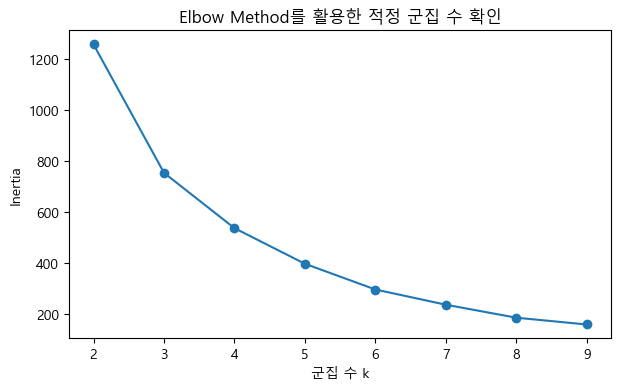

In [255]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method를 활용한 적정 군집 수 확인")
plt.xlabel("군집 수 k")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()


,k,silhouette,davies_bouldin,calinski_harabasz,cluster_counts,min_cluster_size
0,2,0.790825,0.642995,543.979364,"0:576, 1:24",24
1,3,0.685456,0.666287,651.244608,"0:540, 1:12, 2:48",12
2,4,0.561026,0.609297,687.906852,"0:479, 1:12, 2:97, 3:12",12
3,5,0.396658,0.709264,747.311112,"0:207, 1:12, 2:84, 3:12, 4:285",12
4,6,0.430688,0.722509,839.011017,"0:213, 1:12, 2:36, 3:12, 4:168, 5:159",12
5,7,0.438673,0.614954,897.159983,"0:195, 1:12, 2:12, 3:250, 4:12, 5:24, 6:95",12
6,8,0.453916,0.643012,999.361687,"0:140, 1:12, 2:67, 3:12, 4:179, 5:12, 6:24, 7:154",12
7,9,0.452109,0.670960,1029.230800,"0:155, 1:10, 2:24, 3:179, 4:140, 5:12, 6:66, 7...",2


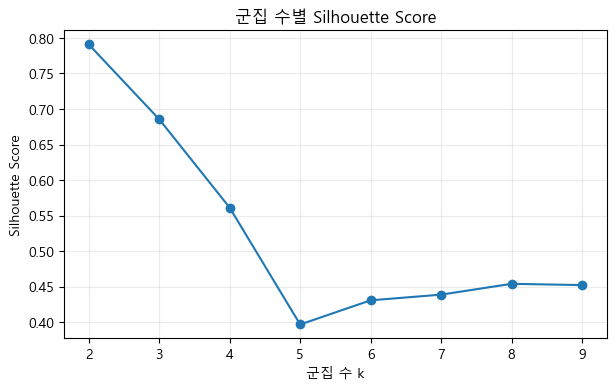

In [256]:
k_eval_rows = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    counts = pd.Series(labels).value_counts().sort_index()
    k_eval_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "cluster_counts": ", ".join(f"{idx}:{cnt}" for idx, cnt in counts.items()),
        "min_cluster_size": int(counts.min()),
    })

k_evaluation = pd.DataFrame(k_eval_rows)
display(k_evaluation)

plt.figure(figsize=(7, 4))
plt.plot(k_evaluation["k"], k_evaluation["silhouette"], marker="o")
plt.title("군집 수별 Silhouette Score")
plt.xlabel("군집 수 k")
plt.ylabel("Silhouette Score")
plt.xticks(k_evaluation["k"])
plt.grid(alpha=0.25)
plt.show()


Silhouette Score만 보면 k=2가 가장 높게 나타났지만, k=2는 상권을 너무 단순하게 일반형과 특이형 정도로만 나누는 한계가 있었다. 본 분석에서는 백현동의 프랜차이즈 침투형, 정자1동의 초고활성 대형 상권형, 중상위 활성 상권형, 일반/기준 상권형을 구분하기 위해 해석 가능성을 고려하여 k=4를 사용하였다.

## 4. 최종 K-Means 군집 생성

Elbow와 Silhouette 결과를 확인한 뒤 최종 군집 수는 4개로 고정한다.

In [257]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
ml_df["cluster"] = kmeans.fit_predict(X_scaled)

ml_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio,cluster
0,2023Q1,41131510,신흥1동,수정구,781803.43,2.533850e+10,999168.0,4.893482,0
1,2023Q2,41131510,신흥1동,수정구,808998.65,2.648371e+10,1092318.0,4.843364,0
2,2023Q3,41131510,신흥1동,수정구,807881.77,2.583415e+10,1113248.0,5.156809,0
3,2023Q4,41131510,신흥1동,수정구,860145.94,2.626346e+10,1072653.0,5.164021,0
4,2024Q1,41131510,신흥1동,수정구,779105.37,2.431509e+10,1043582.0,5.277544,0


## 5. 군집별 특성 확인

In [258]:
cluster_counts = ml_df["cluster"].value_counts().sort_index()
cluster_counts


cluster
0    479
1     12
2     97
3     12
Name: count, dtype: int64

In [259]:
cluster_summary = ml_df.groupby("cluster")[FEATURES].mean()
display(cluster_summary)


,floating_pop,sales_amt,sales_cnt,franchise_ratio
cluster,,,,
0,1.784626e+06,9.615703e+10,1.977174e+06,5.423618
1,4.613867e+06,3.585017e+12,1.196821e+08,16.960166
2,5.913653e+06,4.604991e+11,1.030029e+07,8.163951
3,6.434185e+06,1.331472e+13,2.278689e+08,8.459322


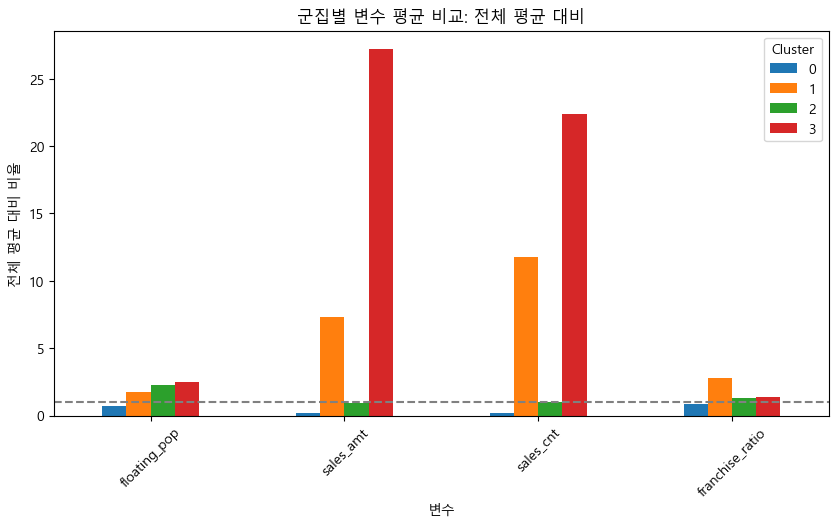

In [260]:
cluster_compare = cluster_summary / ml_df[FEATURES].mean()

ax = cluster_compare.T.plot(kind="bar", figsize=(10, 5))
ax.axhline(1, linestyle="--", color="gray")
ax.set_title("군집별 변수 평균 비교: 전체 평균 대비")
ax.set_xlabel("변수")
ax.set_ylabel("전체 평균 대비 비율")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Cluster")
plt.show()


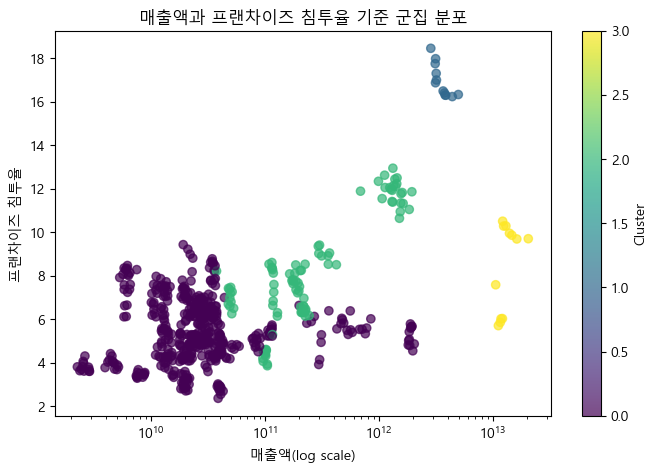

In [261]:
plt.figure(figsize=(8, 5))
plt.scatter(
    ml_df["sales_amt"],
    ml_df["franchise_ratio"],
    c=ml_df["cluster"],
    alpha=0.7,
)

plt.xscale("log")
plt.title("매출액과 프랜차이즈 침투율 기준 군집 분포")
plt.xlabel("매출액(log scale)")
plt.ylabel("프랜차이즈 침투율")
plt.colorbar(label="Cluster")
plt.show()


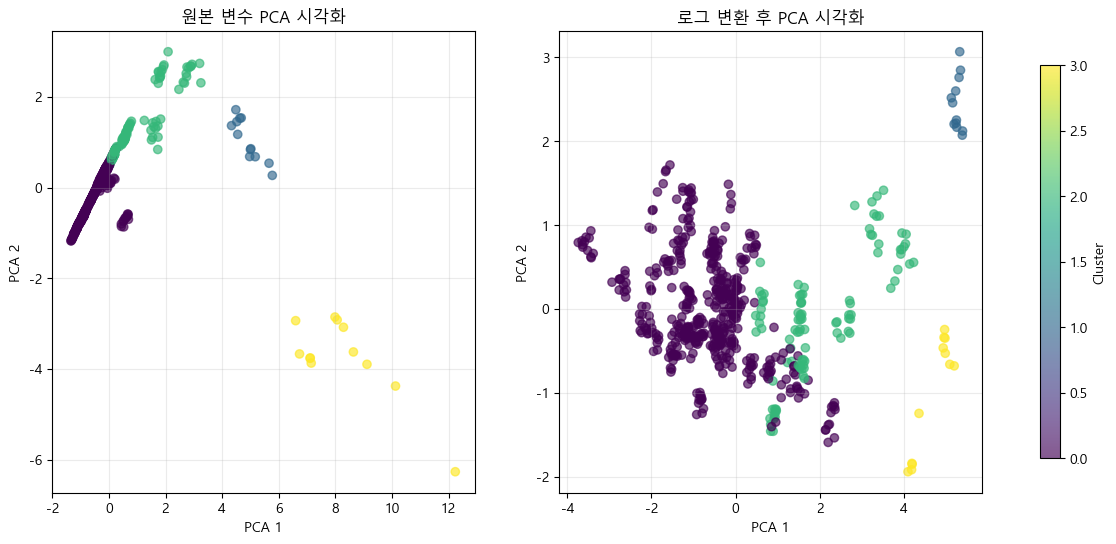

원본 PCA 2축 설명력: 0.8751
로그 변환 PCA 2축 설명력: 0.9082


In [262]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ml_df["pca1"] = X_pca[:, 0]
ml_df["pca2"] = X_pca[:, 1]

# 시각화용 로그 변환: 원본 K-Means 결과는 유지하고, 그림에서만 극단값 눌림을 완화한다.
X_vis = ml_df[FEATURES].copy()
for col in ["floating_pop", "sales_amt", "sales_cnt"]:
    X_vis[col] = np.log1p(X_vis[col])

X_vis_scaled = StandardScaler().fit_transform(X_vis)
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_vis_scaled)

ml_df["pca_log1"] = X_pca_vis[:, 0]
ml_df["pca_log2"] = X_pca_vis[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = axes[0].scatter(
    ml_df["pca1"],
    ml_df["pca2"],
    c=ml_df["cluster"],
    alpha=0.65,
    s=36,
)
axes[0].set_title("원본 변수 PCA 시각화")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(alpha=0.25)

scatter2 = axes[1].scatter(
    ml_df["pca_log1"],
    ml_df["pca_log2"],
    c=ml_df["cluster"],
    alpha=0.65,
    s=36,
)
axes[1].set_title("로그 변환 후 PCA 시각화")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(alpha=0.25)

fig.colorbar(scatter2, ax=axes, label="Cluster", shrink=0.85)
plt.show()

print("원본 PCA 2축 설명력:", round(pca.explained_variance_ratio_.sum(), 4))
print("로그 변환 PCA 2축 설명력:", round(pca_vis.explained_variance_ratio_.sum(), 4))


| cluster | 특징 | 해석 이름 |
| ------: | --- | --- |
| 0 | 유동인구, 매출액, 매출건수, 프랜차이즈 침투율 모두 가장 낮음 | **일반/저활력 상권형** |
| 1 | 매출액·매출건수가 높고, 특히 프랜차이즈 침투율이 압도적으로 높음 | **프랜차이즈 침투 고위험형** |
| 2 | 유동인구는 높지만 매출액·매출건수는 cluster 1, 3보다 낮음 | **중상위 활성 상권형** |
| 3 | 유동인구, 매출액, 매출건수 모두 최고 수준 | **초고활성 대형 상권형** |

cluster 1은 평균 프랜차이즈 침투율이 약 16.96으로 가장 높아 젠트리피케이션 위험 후보군으로 볼 수 있다. 정자1동이 포함된 cluster 3은 프랜차이즈 침투율보다는 매출액과 매출건수가 압도적으로 높은 초고활성 대형 상권에 가깝다.

In [263]:
CLUSTER_LABELS = {
    0: "일반/기준 상권형",
    1: "프랜차이즈 침투 고위험형",
    2: "중상위 활성 상권형",
    3: "초고활성 대형 상권형",
}

ml_df["cluster_label"] = ml_df["cluster"].map(CLUSTER_LABELS)

ml_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio,cluster,pca1,pca2,pca_log1,pca_log2,cluster_label
0,2023Q1,41131510,신흥1동,수정구,781803.43,2.533850e+10,999168.0,4.893482,0,-0.875671,-0.591910,-1.152426,0.054750,일반/기준 상권형
1,2023Q2,41131510,신흥1동,수정구,808998.65,2.648371e+10,1092318.0,4.843364,0,-0.876821,-0.596346,-1.093429,0.006945,일반/기준 상권형
2,2023Q3,41131510,신흥1동,수정구,807881.77,2.583415e+10,1113248.0,5.156809,0,-0.822820,-0.528017,-1.041776,0.121433,일반/기준 상권형
3,2023Q4,41131510,신흥1동,수정구,860145.94,2.626346e+10,1072653.0,5.164021,0,-0.811157,-0.511109,-1.013259,0.101479,일반/기준 상권형
4,2024Q1,41131510,신흥1동,수정구,779105.37,2.431509e+10,1043582.0,5.277544,0,-0.809547,-0.508711,-1.085820,0.194992,일반/기준 상권형


## 6. 행정동별 군집 확인

In [264]:
dong_cluster = (
    ml_df.groupby(["adm_dong_cd", "adm_dong_nm", "gu", "cluster", "cluster_label"])
    .size()
    .reset_index(name="quarter_count")
    .sort_values(
        ["cluster", "quarter_count", "gu", "adm_dong_nm"],
        ascending=[True, False, True, True],
    )
)

display(dong_cluster)


,adm_dong_cd,adm_dong_nm,gu,cluster,cluster_label,quarter_count
49,41135665,구미1동,분당구,0,일반/기준 상권형,12
29,41135510,분당동,분당구,0,일반/기준 상권형,12
38,41135590,서현2동,분당구,0,일반/기준 상권형,12
31,41135530,수내2동,분당구,0,일반/기준 상권형,12
32,41135540,수내3동,분당구,0,일반/기준 상권형,12
42,41135630,야탑2동,분당구,0,일반/기준 상권형,12
43,41135640,야탑3동,분당구,0,일반/기준 상권형,12
39,41135600,이매1동,분당구,0,일반/기준 상권형,12
40,41135610,이매2동,분당구,0,일반/기준 상권형,12
35,41135560,정자2동,분당구,0,일반/기준 상권형,12


| cluster | 주요 행정동 | 해석 |
| ------: | --- | --- |
| 0 | 대부분의 행정동 | **일반/기준 상권형** |
| 1 | 백현동 | **프랜차이즈 침투 고위험형** |
| 2 | 구미동, 삼평동, 서현1동, 성남동, 수내1동, 야탑1동, 위례동, 운중동 등 | **중상위 활성 상권형** |
| 3 | 정자1동 | **초고활성 대형 상권형** |

젠트리피케이션 위험 후보로는 백현동을 우선 확인하는 것이 적절하다. cluster 1은 프랜차이즈 침투율이 가장 높고 매출액, 매출건수도 높은 편이기 때문이다.

## 7. 군집 이동 행정동 확인

In [265]:
changed_dongs = (
    ml_df.groupby(["adm_dong_cd", "adm_dong_nm", "gu"])["cluster"]
    .nunique()
    .reset_index(name="cluster_nunique")
)

changed_dongs = changed_dongs[changed_dongs["cluster_nunique"] > 1]
changed_dongs = changed_dongs.sort_values(["gu", "adm_dong_nm"])

display(changed_dongs)


,adm_dong_cd,adm_dong_nm,gu,cluster_nunique
46,41135662,금곡동,분당구,2
49,41135680,운중동,분당구,2
16,41131650,시흥동,수정구,2


In [266]:
changed_dong_codes = changed_dongs["adm_dong_cd"].tolist()

changed_history = (
    ml_df[ml_df["adm_dong_cd"].isin(changed_dong_codes)]
    [ID_COLUMNS + FEATURES + ["cluster", "cluster_label"]]
    .sort_values(["adm_dong_nm", "base_quarter"])
)

display(changed_history)


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio,cluster,cluster_label
552,2023Q1,41135662,금곡동,분당구,3798015.18,1.039082e+11,2914780.0,5.240267,0,일반/기준 상권형
553,2023Q2,41135662,금곡동,분당구,4088668.28,1.088565e+11,3178984.0,5.228077,0,일반/기준 상권형
554,2023Q3,41135662,금곡동,분당구,3974314.58,1.104807e+11,3207754.0,5.427580,0,일반/기준 상권형
555,2023Q4,41135662,금곡동,분당구,3845382.91,1.156123e+11,3198958.0,5.552618,0,일반/기준 상권형
556,2024Q1,41135662,금곡동,분당구,3804589.81,1.154404e+11,3161236.0,5.733362,0,일반/기준 상권형
557,2024Q2,41135662,금곡동,분당구,3999201.11,1.148907e+11,3171866.0,5.653894,0,일반/기준 상권형
558,2024Q3,41135662,금곡동,분당구,4320448.28,1.132683e+11,3155793.0,5.497409,0,일반/기준 상권형
559,2024Q4,41135662,금곡동,분당구,4314774.43,1.118664e+11,3086137.0,5.437853,0,일반/기준 상권형
560,2025Q1,41135662,금곡동,분당구,4063226.99,1.062754e+11,2840026.0,5.497668,0,일반/기준 상권형
561,2025Q2,41135662,금곡동,분당구,4346908.03,1.102764e+11,3028353.0,5.336126,0,일반/기준 상권형


| 행정동 | 군집 변화 | 해석 |
| --- | --- | --- |
| 금곡동 | 2025Q3만 0 → 2 | 일시적 활성화 |
| 시흥동 | 2025Q3만 0 → 2 | 일시적 유입/소비 증가 |
| 운중동 | 2023Q2부터 0 → 2 유지 | 중상위 활성 상권으로 전환 후 유지 |

금곡동과 시흥동은 2025년 3분기에만 중상위 활성 상권형으로 이동한 뒤 다시 일반/저활력 상권형으로 돌아와 일시적 활성화로 해석된다. 운중동은 2023년 2분기부터 중상위 활성 상권형으로 이동한 후 분석 기간 동안 해당 유형을 유지하여, 상권 활성 수준이 안정적으로 상승한 지역으로 볼 수 있다.

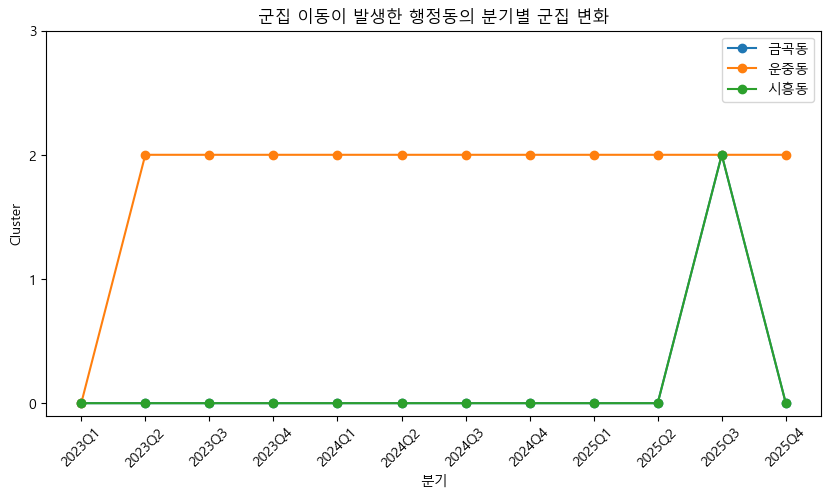

In [267]:
plt.figure(figsize=(10, 5))

for dong_cd in changed_dong_codes:
    temp = changed_history[changed_history["adm_dong_cd"] == dong_cd]
    dong_name = temp["adm_dong_nm"].iloc[0]
    plt.plot(temp["base_quarter"], temp["cluster"], marker="o", label=dong_name)

plt.title("군집 이동이 발생한 행정동의 분기별 군집 변화")
plt.xlabel("분기")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.yticks([0, 1, 2, 3])
plt.legend()
plt.show()


In [268]:
final_cluster_metrics = pd.DataFrame({
    "metric": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
    "value": [
        silhouette_score(X_scaled, ml_df["cluster"]),
        davies_bouldin_score(X_scaled, ml_df["cluster"]),
        calinski_harabasz_score(X_scaled, ml_df["cluster"]),
    ],
})

final_cluster_metrics


,metric,value
0,Silhouette,0.561026
1,Davies-Bouldin,0.609297
2,Calinski-Harabasz,687.906852


## 8. 결과 저장

In [269]:
save_columns = ID_COLUMNS + FEATURES + ["cluster", "cluster_label"]

ml_df[save_columns].to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
OUTPUT_PATH


WindowsPath('output/ML용_kmeans_result_4vars.csv')

## 9. 단일 변수 및 변화율 분석

4개 변수를 동시에 활용한 K-Means 결과를 해석한 뒤, 각 변수가 단독으로 어떤 수준 구분을 만드는지 확인한다. 값의 쏠림이 큰 변수는 log1p 변환이나 QoQ 변화율을 추가로 검토한다.


### 9.1 유동인구 규모


In [270]:
# 분기, 행정동, 구, 유동인구로 필요한 컬럼을 꺼내서 확인
floating_df = ml_df[ID_COLUMNS + ["floating_pop"]].copy()
floating_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop
0,2023Q1,41131510,신흥1동,수정구,781803.43
1,2023Q2,41131510,신흥1동,수정구,808998.65
2,2023Q3,41131510,신흥1동,수정구,807881.77
3,2023Q4,41131510,신흥1동,수정구,860145.94
4,2024Q1,41131510,신흥1동,수정구,779105.37


In [271]:
X_floating = floating_df[["floating_pop"]]
X_floating.head()


,floating_pop
0,781803.43
1,808998.65
2,807881.77
3,860145.94
4,779105.37


In [272]:
# 이제 유동인구 넣을 데이터 봤으니 스케일링 실행
scaler_floating = StandardScaler()
X_floating_scaled = scaler_floating.fit_transform(X_floating)

X_floating_scaled[:5]


array([[-0.90597918],
       [-0.89244109],
       [-0.89299709],
       [-0.86697939],
       [-0.90732231]])

In [273]:
# 유동인구 기준으로 k-means 실행
kmeans_floating = KMeans(n_clusters=3, random_state= RANDOM_STATE, n_init=10)
floating_df["floating_cluster_raw"] = kmeans_floating.fit_predict(X_floating_scaled)
floating_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,floating_cluster_raw
0,2023Q1,41131510,신흥1동,수정구,781803.43,2
1,2023Q2,41131510,신흥1동,수정구,808998.65,2
2,2023Q3,41131510,신흥1동,수정구,807881.77,2
3,2023Q4,41131510,신흥1동,수정구,860145.94,2
4,2024Q1,41131510,신흥1동,수정구,779105.37,2


In [274]:
floating_order = (floating_df.groupby("floating_cluster_raw"))["floating_pop"].mean().sort_values().index.tolist()
floating_order


[2, 0, 1]

In [275]:
floating_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(floating_order)
}

floating_df["floating_cluster"] = floating_df["floating_cluster_raw"].map(floating_label_map)

floating_df["floating_level"] = floating_df["floating_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

floating_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,floating_cluster_raw,floating_cluster,floating_level
0,2023Q1,41131510,신흥1동,수정구,781803.43,2,0,낮음
1,2023Q2,41131510,신흥1동,수정구,808998.65,2,0,낮음
2,2023Q3,41131510,신흥1동,수정구,807881.77,2,0,낮음
3,2023Q4,41131510,신흥1동,수정구,860145.94,2,0,낮음
4,2024Q1,41131510,신흥1동,수정구,779105.37,2,0,낮음


In [276]:
floating_df.groupby("floating_level")["floating_pop"].mean().reindex(["낮음", "중간", "높음"])


floating_level
낮음    1.235445e+06
중간    3.239139e+06
높음    6.736080e+06
Name: floating_pop, dtype: float64

In [277]:
# 이제 각각 유동인구 그룹이 몇개가 있는지 확인
floating_summary = (
    floating_df.groupby("floating_level")["floating_pop"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(floating_summary)


,count,mean,min,max
floating_level,,,,
낮음,327,1.235445e+06,150045.93,2216297.53
중간,195,3.239139e+06,2259012.01,4891474.15
높음,78,6.736080e+06,5044376.66,11222106.41


유동인구를 단일 변수로 K-Means 군집화한 결과, 전체 600개 행정동-분기 관측치는 유동인구 낮음 327개, 중간 195개, 높음 78개로 구분되었다.

낮음 그룹의 평균 유동인구는 약 123만 명, 중간 그룹은 약 324만 명, 높음 그룹은 약 674만 명으로 나타났다. 이를 통해 행정동별 상권 유입 규모가 세 단계로 구분됨을 확인하였다.

유동인구가 높은 그룹은 방문자 유입이 많은 상권으로 해석할 수 있으나, 유동인구만으로는 실제 소비 활동이나 프랜차이즈화 정도를 판단할 수 없기 때문에 이후 매출액, 매출건수, 프랜차이즈 침투율과 함께 종합적으로 해석할 필요가 있다.

In [278]:
floating_silhouette = silhouette_score(
    X_floating_scaled,
    floating_df["floating_cluster"]
)

print("유동인구 단일 변수 Silhouette Score:", floating_silhouette)


유동인구 단일 변수 Silhouette Score: 0.5905923168740247


유동인구 단일 변수 K-Means는 유동인구 규모를 낮음, 중간, 높음 3개 수준으로 구분하기 위해 k=3으로 설정하였다. 분석 결과 Silhouette Score는 0.591로 나타났으며, 이는 유동인구 기준 군집이 비교적 해석 가능한 수준으로 분리되었음을 의미한다.

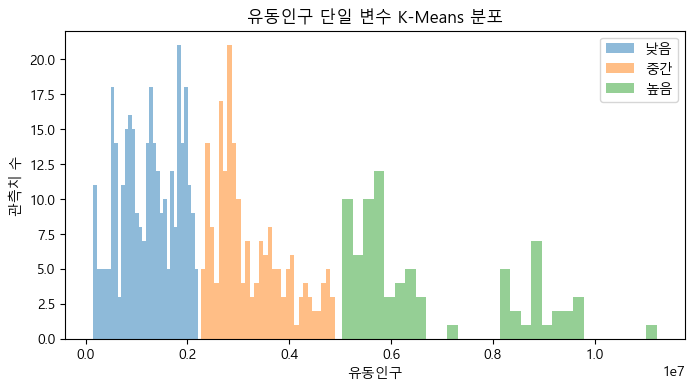

In [279]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = floating_df[floating_df["floating_level"] == level]
    plt.hist(
        temp["floating_pop"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("유동인구 단일 변수 K-Means 분포")
plt.xlabel("유동인구")
plt.ylabel("관측치 수")
plt.legend()
plt.show()


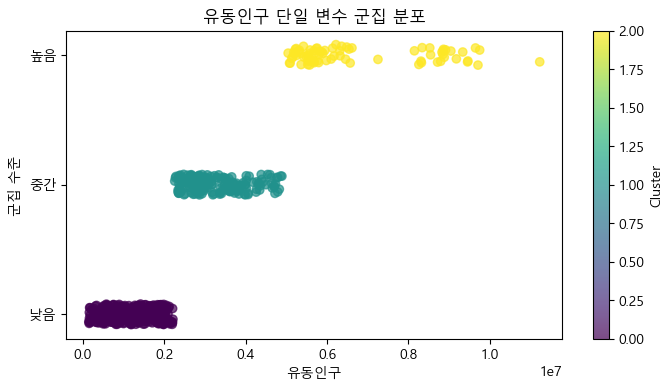

In [280]:
floating_df["floating_level_num"] = floating_df["floating_level"].map(LEVEL_TO_NUM)

rng = np.random.default_rng(RANDOM_STATE)
y_jitter = floating_df["floating_level_num"] + rng.uniform(-0.08, 0.08, len(floating_df))

plt.figure(figsize=(8, 4))
plt.scatter(
    floating_df["floating_pop"],
    y_jitter,
    c=floating_df["floating_level_num"],
    cmap="viridis",
    alpha=0.7,
)

plt.yticks([0, 1, 2], LEVEL_ORDER)
plt.title("유동인구 단일 변수 군집 분포")
plt.xlabel("유동인구")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()


### 9.2 유동인구 QoQ 변화율


In [281]:
floating_df["year"] = floating_df["base_quarter"].str[:4].astype(int)
floating_df["quarter"] = floating_df["base_quarter"].str[-1].astype(int)

floating_df = floating_df.sort_values(["adm_dong_cd", "year", "quarter"]).copy()

floating_df.head(15)


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,floating_cluster_raw,floating_cluster,floating_level,floating_level_num,year,quarter
0,2023Q1,41131510,신흥1동,수정구,781803.43,2,0,낮음,0,2023,1
1,2023Q2,41131510,신흥1동,수정구,808998.65,2,0,낮음,0,2023,2
2,2023Q3,41131510,신흥1동,수정구,807881.77,2,0,낮음,0,2023,3
3,2023Q4,41131510,신흥1동,수정구,860145.94,2,0,낮음,0,2023,4
4,2024Q1,41131510,신흥1동,수정구,779105.37,2,0,낮음,0,2024,1
5,2024Q2,41131510,신흥1동,수정구,755850.19,2,0,낮음,0,2024,2
6,2024Q3,41131510,신흥1동,수정구,726410.57,2,0,낮음,0,2024,3
7,2024Q4,41131510,신흥1동,수정구,761163.70,2,0,낮음,0,2024,4
8,2025Q1,41131510,신흥1동,수정구,698569.95,2,0,낮음,0,2025,1
9,2025Q2,41131510,신흥1동,수정구,763418.91,2,0,낮음,0,2025,2


In [282]:
# 행정동별 전분기 대비 유동인구 변화율 계산
floating_df["floating_pop_qoq"] = (
    floating_df.groupby("adm_dong_cd")["floating_pop"]
    .pct_change()
)

floating_df[[
    "base_quarter",
    "adm_dong_cd",
    "adm_dong_nm",
    "gu",
    "floating_pop",
    "floating_pop_qoq"
]].head(20)


,base_quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,floating_pop_qoq
0,2023Q1,41131510,신흥1동,수정구,781803.43,NaN
1,2023Q2,41131510,신흥1동,수정구,808998.65,0.034785
2,2023Q3,41131510,신흥1동,수정구,807881.77,-0.001381
3,2023Q4,41131510,신흥1동,수정구,860145.94,0.064693
4,2024Q1,41131510,신흥1동,수정구,779105.37,-0.094217
5,2024Q2,41131510,신흥1동,수정구,755850.19,-0.029849
6,2024Q3,41131510,신흥1동,수정구,726410.57,-0.038949
7,2024Q4,41131510,신흥1동,수정구,761163.70,0.047842
8,2025Q1,41131510,신흥1동,수정구,698569.95,-0.082234
9,2025Q2,41131510,신흥1동,수정구,763418.91,0.092831


In [283]:
floating_df["floating_pop_qoq"].isna().sum()


np.int64(50)

In [284]:
floating_df["floating_pop_qoq"].describe()


count    550.000000
mean       0.009524
std        0.080089
min       -0.210707
25%       -0.039999
50%        0.004321
75%        0.058445
max        0.855958
Name: floating_pop_qoq, dtype: float64

In [285]:
# 극단값 완화를 위해 상·하위 1% 기준으로 clipping한다.
lower = floating_df["floating_pop_qoq"].quantile(0.01)
upper = floating_df["floating_pop_qoq"].quantile(0.99)

floating_df["floating_pop_qoq_clip"] = floating_df["floating_pop_qoq"].clip(lower, upper)

print("하위 1%:", lower)
print("상위 1%:", upper)

floating_df[["floating_pop_qoq", "floating_pop_qoq_clip"]].describe()


하위 1%: -0.1504491528946838
상위 1%: 0.18677536708559797


,floating_pop_qoq,floating_pop_qoq_clip
count,550.000000,550.000000
mean,0.009524,0.008320
std,0.080089,0.070347
min,-0.210707,-0.150449
25%,-0.039999,-0.039999
50%,0.004321,0.004321
75%,0.058445,0.058445
max,0.855958,0.186775


유동인구 QoQ는 일부 극단적 증가값이 존재하여, K-Means 군집 왜곡을 줄이기 위해 상·하위 1% 기준으로 clipping 처리하였다.

In [286]:
floating_qoq_clip_col = "floating_pop_qoq_clip"
floating_qoq_clip_df = floating_df.dropna(subset=[floating_qoq_clip_col]).copy()

X_floating_qoq_clip = floating_qoq_clip_df[[floating_qoq_clip_col]]
scaler_floating_qoq_clip = StandardScaler()
X_floating_qoq_clip_scaled = scaler_floating_qoq_clip.fit_transform(X_floating_qoq_clip)

kmeans_floating_qoq_clip = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
floating_qoq_clip_df["floating_qoq_cluster_raw"] = kmeans_floating_qoq_clip.fit_predict(
    X_floating_qoq_clip_scaled
)

floating_qoq_clip_silhouette = silhouette_score(
    X_floating_qoq_clip_scaled,
    floating_qoq_clip_df["floating_qoq_cluster_raw"],
)
print("Silhouette Score:", round(floating_qoq_clip_silhouette, 4))


Silhouette Score: 0.5292


In [287]:
floating_qoq_clip_order = (
    floating_qoq_clip_df.groupby("floating_qoq_cluster_raw")[floating_qoq_clip_col]
    .mean()
    .sort_values()
    .index
)

floating_qoq_clip_label_map = {
    old_label: LEVEL_ORDER[idx]
    for idx, old_label in enumerate(floating_qoq_clip_order)
}

floating_qoq_clip_df["floating_qoq_level"] = floating_qoq_clip_df[
    "floating_qoq_cluster_raw"
].map(floating_qoq_clip_label_map)

floating_qoq_clip_df["floating_qoq_level"].value_counts()


floating_qoq_level
중간    240
낮음    165
높음    145
Name: count, dtype: int64

In [288]:
floating_qoq_summary = (
    floating_qoq_clip_df.groupby("floating_qoq_level")[floating_qoq_clip_col]
    .agg(["count", "mean", "min", "max"])
    .reindex(LEVEL_ORDER)
)

display(floating_qoq_summary)


,count,mean,min,max
floating_qoq_level,,,,
낮음,165,-0.071352,-0.150449,-0.031540
중간,240,0.008438,-0.031168,0.053118
높음,145,0.098786,0.055036,0.186775


In [289]:
floating_qoq_clip_df[
    floating_qoq_clip_df["floating_qoq_level"] == LEVEL_ORDER[2]
]["base_quarter"].value_counts().sort_index()


base_quarter
2023Q2    36
2023Q3     3
2023Q4     8
2024Q1     2
2024Q2    15
2024Q3     5
2024Q4     7
2025Q2    38
2025Q3    29
2025Q4     2
Name: count, dtype: int64

#### 분기 전체 흐름을 조정한 QoQ


In [290]:
# 분기별 중앙값 제거
floating_df["floating_pop_qoq_adj"] = (
    floating_df["floating_pop_qoq_clip"]
    - floating_df.groupby("base_quarter")["floating_pop_qoq_clip"].transform("median")
)

floating_df[[
    "base_quarter",
    "adm_dong_cd",
    "adm_dong_nm",
    "floating_pop_qoq_clip",
    "floating_pop_qoq_adj"
]].head(20)


,base_quarter,adm_dong_cd,adm_dong_nm,floating_pop_qoq_clip,floating_pop_qoq_adj
0,2023Q1,41131510,신흥1동,NaN,NaN
1,2023Q2,41131510,신흥1동,0.034785,-0.042551
2,2023Q3,41131510,신흥1동,-0.001381,0.019453
3,2023Q4,41131510,신흥1동,0.064693,0.079390
4,2024Q1,41131510,신흥1동,-0.094217,-0.053779
5,2024Q2,41131510,신흥1동,-0.029849,-0.063643
6,2024Q3,41131510,신흥1동,-0.038949,-0.050133
7,2024Q4,41131510,신흥1동,0.047842,0.035715
8,2025Q1,41131510,신흥1동,-0.082234,-0.023322
9,2025Q2,41131510,신흥1동,0.092831,0.022561


In [291]:
floating_qoq_adj_col = "floating_pop_qoq_adj"
floating_qoq_adj_df = floating_df.dropna(subset=[floating_qoq_adj_col]).copy()

X_floating_qoq_adj = floating_qoq_adj_df[[floating_qoq_adj_col]]
scaler_floating_qoq_adj = StandardScaler()
X_floating_qoq_adj_scaled = scaler_floating_qoq_adj.fit_transform(X_floating_qoq_adj)

kmeans_floating_qoq_adj = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
floating_qoq_adj_df["floating_qoq_adj_cluster_raw"] = kmeans_floating_qoq_adj.fit_predict(
    X_floating_qoq_adj_scaled
)

floating_qoq_adj_silhouette = silhouette_score(
    X_floating_qoq_adj_scaled,
    floating_qoq_adj_df["floating_qoq_adj_cluster_raw"],
)
print("Silhouette Score:", round(floating_qoq_adj_silhouette, 4))


Silhouette Score: 0.5555


In [292]:
floating_qoq_adj_order = (
    floating_qoq_adj_df.groupby("floating_qoq_adj_cluster_raw")[floating_qoq_adj_col]
    .mean()
    .sort_values()
    .index
)

floating_qoq_adj_label_map = {
    old_label: LEVEL_ORDER[idx]
    for idx, old_label in enumerate(floating_qoq_adj_order)
}

floating_qoq_adj_df["floating_qoq_adj_level"] = floating_qoq_adj_df[
    "floating_qoq_adj_cluster_raw"
].map(floating_qoq_adj_label_map)

floating_qoq_adj_df["floating_qoq_adj_level"].value_counts()


floating_qoq_adj_level
중간    360
높음     97
낮음     93
Name: count, dtype: int64

In [293]:
floating_qoq_adj_summary = (
    floating_qoq_adj_df.groupby("floating_qoq_adj_level")[floating_qoq_adj_col]
    .agg(["count", "mean", "min", "max"])
    .reindex(LEVEL_ORDER)
)

display(floating_qoq_adj_summary)


,count,mean,min,max
floating_qoq_adj_level,,,,
낮음,93,-0.071400,-0.170943,-0.035914
중간,360,0.000752,-0.035275,0.038489
높음,97,0.077439,0.039534,0.201472


In [294]:
floating_qoq_adj_df[
    floating_qoq_adj_df["floating_qoq_adj_level"] == LEVEL_ORDER[2]
]["base_quarter"].value_counts().sort_index()


base_quarter
2023Q2     7
2023Q3     7
2023Q4    10
2024Q1     6
2024Q2     8
2024Q3     5
2024Q4     7
2025Q1     2
2025Q2    12
2025Q3    17
2025Q4    16
Name: count, dtype: int64

단순 전분기 대비 유동인구 증가율은 특정 분기 전체의 계절성 영향을 받을 수 있어, 분기별 중앙값을 제거한 조정 변화율을 생성하였다. 이를 통해 같은 분기 안에서 상대적으로 유동인구 증가가 큰 행정동을 구분하였다.

In [295]:
print("Silhouette Score:", round(floating_qoq_adj_silhouette, 4))


Silhouette Score: 0.5555


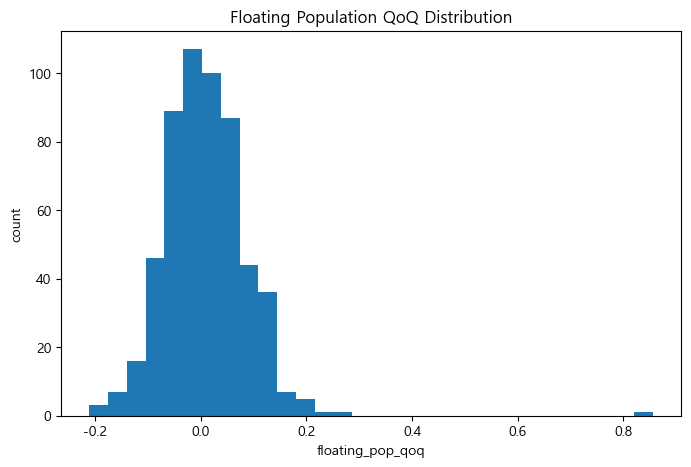

In [296]:
# 원본 qoq 분포 확인
plt.figure(figsize=(8, 5))
plt.hist(floating_df["floating_pop_qoq"].dropna(), bins=30)
plt.title("Floating Population QoQ Distribution")
plt.xlabel("floating_pop_qoq")
plt.ylabel("count")
plt.show()


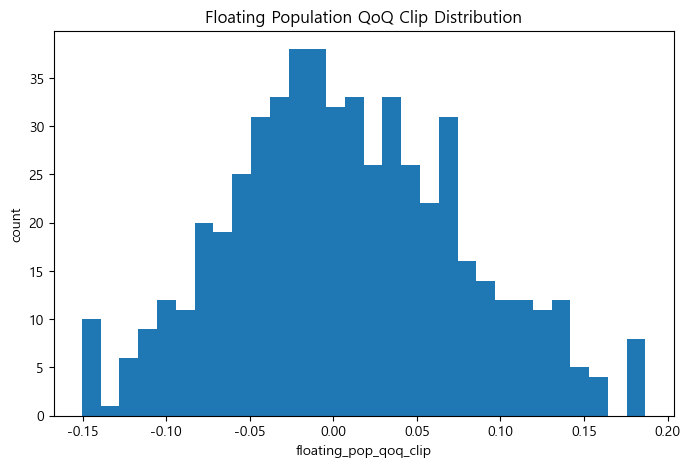

In [297]:
#clip후 시각화
plt.figure(figsize=(8, 5))
plt.hist(floating_df["floating_pop_qoq_clip"].dropna(), bins=30)
plt.title("Floating Population QoQ Clip Distribution")
plt.xlabel("floating_pop_qoq_clip")
plt.ylabel("count")
plt.show()


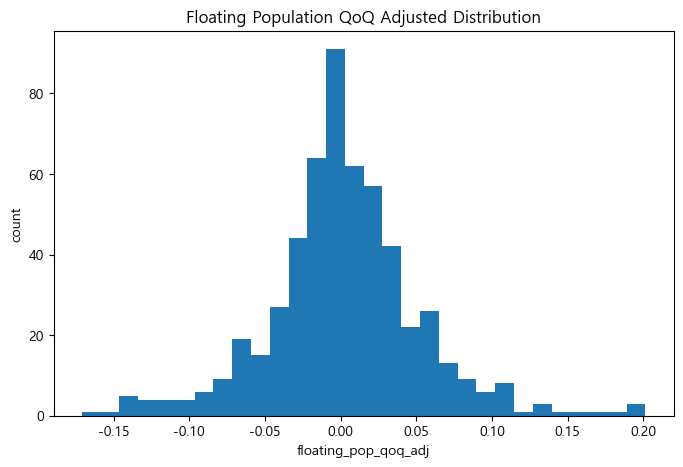

In [298]:
# 중앙값 제거 후 시각화
plt.figure(figsize=(8, 5))
plt.hist(floating_df["floating_pop_qoq_adj"].dropna(), bins=30)
plt.title("Floating Population QoQ Adjusted Distribution")
plt.xlabel("floating_pop_qoq_adj")
plt.ylabel("count")
plt.show()


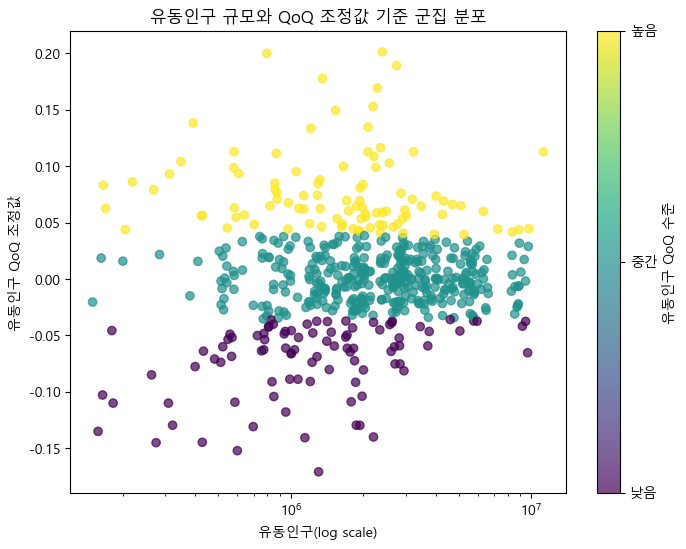

In [299]:
# 유동인구 QoQ 조정 군집 결과가 들어있는 데이터프레임
plot_df = floating_qoq_adj_df.copy()

level_map = {
    "낮음": 0,
    "중간": 1,
    "높음": 2
}

plot_df["floating_qoq_level_num"] = plot_df["floating_qoq_adj_level"].map(level_map)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    plot_df["floating_pop"],
    plot_df["floating_pop_qoq_adj"],
    c=plot_df["floating_qoq_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.xscale("log")
plt.xlabel("유동인구(log scale)")
plt.ylabel("유동인구 QoQ 조정값")
plt.title("유동인구 규모와 QoQ 조정값 기준 군집 분포")

cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["낮음", "중간", "높음"])
cbar.set_label("유동인구 QoQ 수준")

plt.show()


유동인구 규모와 관계없이, 같은 분기 내에서 상대적으로 유동인구가 증가한 행정동-분기와 감소한 행정동-분기가 구분되었다.

| 후보 변수                   |     점수 | 문제              | 판단    |
| ----------------------- | -----: | --------------- | ----- |
| `floating_pop_qoq_clip` | 0.5292 | 특정 분기에 높음 그룹 몰림 | 보류    |
| `floating_pop_qoq_adj`  | 0.5551 | 분기 몰림 완화        | 최종 후보 |


유동인구 변화율은 계절성 및 분기 전체 흐름의 영향을 받을 수 있어, 전분기 대비 변화율을 계산한 뒤 분기별 중앙값을 제거하였다. 조정 후 단일변수 K-Means 결과 Silhouette Score는 0.5551로 나타났고, 높음 그룹의 특정 분기 쏠림도 완화되어 최종 군집 후보 변수로 사용 가능하다고 판단하였다.

### 9.3 매출액 규모


In [300]:
sales_amt_df = ml_df[ID_COLUMNS + ["sales_amt"]].copy()
sales_amt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_amt
0,2023Q1,41131510,신흥1동,수정구,2.533850e+10
1,2023Q2,41131510,신흥1동,수정구,2.648371e+10
2,2023Q3,41131510,신흥1동,수정구,2.583415e+10
3,2023Q4,41131510,신흥1동,수정구,2.626346e+10
4,2024Q1,41131510,신흥1동,수정구,2.431509e+10


매출액은 값의 범위가 크고 상위 관측치의 영향이 크므로, log1p 변환 후 StandardScaler를 적용한다.


In [301]:
sales_amt_df["sales_amt_log"] = np.log1p(sales_amt_df["sales_amt"])

sales_amt_df[["sales_amt", "sales_amt_log"]].head()


,sales_amt,sales_amt_log
0,2.533850e+10,23.955591
1,2.648371e+10,23.999796
2,2.583415e+10,23.974963
3,2.626346e+10,23.991444
4,2.431509e+10,23.914363


In [302]:
# k-means에 넣을 x 만들기
X_sales_amt = sales_amt_df[["sales_amt_log"]]
X_sales_amt.head()


,sales_amt_log
0,23.955591
1,23.999796
2,23.974963
3,23.991444
4,23.914363


In [303]:
# 스케일링 실행
scaler_sales_amt = StandardScaler()
X_sales_amt_scaled = scaler_sales_amt.fit_transform(X_sales_amt)

X_sales_amt_scaled[:5]


array([[-0.3741983 ],
       [-0.34869082],
       [-0.36301978],
       [-0.35350975],
       [-0.39798798]])

In [304]:
# 매출액 기준으로 3개 그룹 나누기
kmeans_sales_amt = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_amt_df["sales_amt_cluster_raw"] = kmeans_sales_amt.fit_predict(X_sales_amt_scaled)

sales_amt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_amt,sales_amt_log,sales_amt_cluster_raw
0,2023Q1,41131510,신흥1동,수정구,2.533850e+10,23.955591,0
1,2023Q2,41131510,신흥1동,수정구,2.648371e+10,23.999796,0
2,2023Q3,41131510,신흥1동,수정구,2.583415e+10,23.974963,0
3,2023Q4,41131510,신흥1동,수정구,2.626346e+10,23.991444,0
4,2024Q1,41131510,신흥1동,수정구,2.431509e+10,23.914363,0


In [305]:
sales_amt_order = (
    sales_amt_df.groupby("sales_amt_cluster_raw")["sales_amt"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_amt_order


[0, 2, 1]

In [306]:
sales_amt_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_amt_order)
}

sales_amt_df["sales_amt_cluster"] = sales_amt_df["sales_amt_cluster_raw"].map(sales_amt_label_map)

sales_amt_df["sales_amt_level"] = sales_amt_df["sales_amt_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_amt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_amt,sales_amt_log,sales_amt_cluster_raw,sales_amt_cluster,sales_amt_level
0,2023Q1,41131510,신흥1동,수정구,2.533850e+10,23.955591,0,0,낮음
1,2023Q2,41131510,신흥1동,수정구,2.648371e+10,23.999796,0,0,낮음
2,2023Q3,41131510,신흥1동,수정구,2.583415e+10,23.974963,0,0,낮음
3,2023Q4,41131510,신흥1동,수정구,2.626346e+10,23.991444,0,0,낮음
4,2024Q1,41131510,신흥1동,수정구,2.431509e+10,23.914363,0,0,낮음


In [307]:
sales_amt_df.groupby("sales_amt_level")["sales_amt"].mean().reindex(["낮음", "중간", "높음"])


sales_amt_level
낮음    2.355927e+10
중간    2.027107e+11
높음    4.035208e+12
Name: sales_amt, dtype: float64

In [308]:
sales_amt_summary = (
    sales_amt_df.groupby("sales_amt_level")["sales_amt"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_amt_summary)


,count,mean,min,max
sales_amt_level,,,,
낮음,431,2.355927e+10,2.265520e+09,5.659846e+10
중간,104,2.027107e+11,5.941399e+10,5.831210e+11
높음,65,4.035208e+12,6.741808e+11,2.038408e+13


In [309]:
sales_amt_silhouette = silhouette_score(
    X_sales_amt_scaled,
    sales_amt_df["sales_amt_cluster"]
)

print("매출액 단일 변수 Silhouette Score:", sales_amt_silhouette)


매출액 단일 변수 Silhouette Score: 0.6469248594575767


매출액 단일 변수 K-Means는 매출 규모를 낮음, 중간, 높음 3개 수준으로 구분하기 위해 k=3으로 설정하였다. 매출액은 일부 행정동에서 매우 큰 값을 가지므로 log1p 변환 후 StandardScaler를 적용하였다. 분석 결과 Silhouette Score는 0.647로 나타났으며, 이는 매출액 기준 군집이 유동인구 단일 변수보다 더 뚜렷하게 분리되었음을 의미한다.

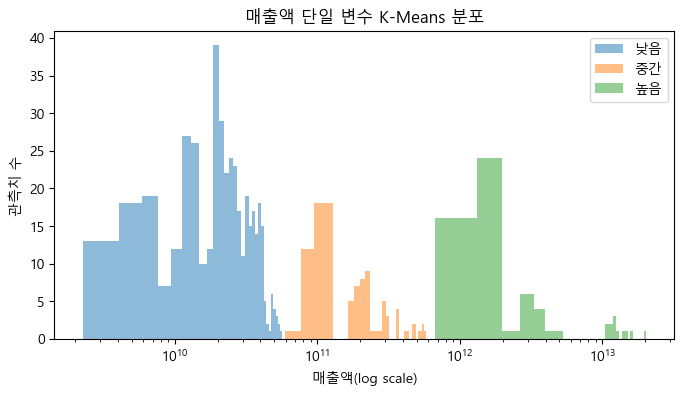

In [310]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_amt_df[sales_amt_df["sales_amt_level"] == level]
    plt.hist(
        temp["sales_amt"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.xscale("log")
plt.title("매출액 단일 변수 K-Means 분포")
plt.xlabel("매출액(log scale)")
plt.ylabel("관측치 수")
plt.legend()
plt.show()


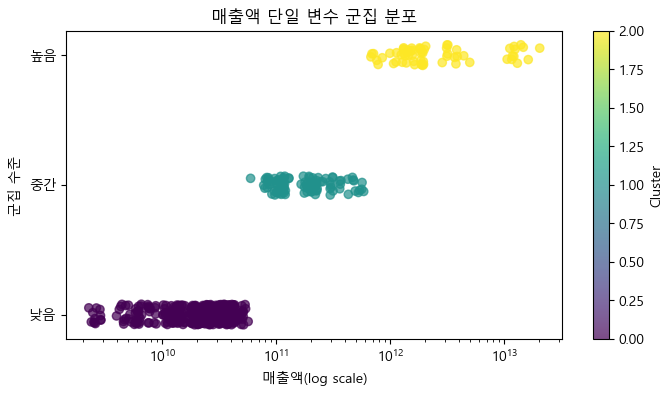

In [311]:
sales_amt_df["sales_amt_level_num"] = sales_amt_df["sales_amt_level"].map(LEVEL_TO_NUM)

rng = np.random.default_rng(RANDOM_STATE)

plt.figure(figsize=(8, 4))

y_jitter = sales_amt_df["sales_amt_level_num"] + rng.uniform(-0.08, 0.08, len(sales_amt_df))

plt.scatter(
    sales_amt_df["sales_amt"],
    y_jitter,
    c=sales_amt_df["sales_amt_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.xscale("log")
plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("매출액 단일 변수 군집 분포")
plt.xlabel("매출액(log scale)")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()


매출액 단일 변수 K-Means 분포를 확인한 결과, 행정동-분기 관측치는 매출 규모에 따라 낮음, 중간, 높음 3개 그룹으로 구분되었다.

매출액은 값의 범위가 매우 크고 일부 행정동에서 극단적으로 높은 값을 보일 수 있으므로, log1p 변환 후 StandardScaler를 적용하여 K-Means를 수행하였다.

분석 결과 매출액 낮음 그룹이 가장 많은 관측치를 차지했으며, 중간 그룹과 높음 그룹은 상대적으로 적은 관측치로 분리되었다. 특히 매출액 높음 그룹은 다른 그룹보다 소비 규모가 확연히 큰 상권으로 해석할 수 있다.

매출액 단일 변수 Silhouette Score는 0.647로 나타나, 매출액 기준 낮음·중간·높음 군집이 비교적 명확하게 분리되었음을 확인하였다.

### 9.4 매출건수 규모


In [312]:
sales_cnt_df = ml_df[ID_COLUMNS + ["sales_cnt"]].copy()

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt
0,2023Q1,41131510,신흥1동,수정구,999168.0
1,2023Q2,41131510,신흥1동,수정구,1092318.0
2,2023Q3,41131510,신흥1동,수정구,1113248.0
3,2023Q4,41131510,신흥1동,수정구,1072653.0
4,2024Q1,41131510,신흥1동,수정구,1043582.0


In [313]:
X_sales_cnt = sales_cnt_df[["sales_cnt"]]

X_sales_cnt.head()


,sales_cnt
0,999168.0
1,1092318.0
2,1113248.0
3,1072653.0
4,1043582.0


In [314]:
scaler_sales_cnt = StandardScaler()
X_sales_cnt_scaled = scaler_sales_cnt.fit_transform(X_sales_cnt)

X_sales_cnt_scaled[:5]


array([[-0.25384463],
       [-0.2512732 ],
       [-0.25069542],
       [-0.25181606],
       [-0.25261857]])

In [315]:
kmeans_sales_cnt = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_cnt_df["sales_cnt_cluster_raw"] = kmeans_sales_cnt.fit_predict(X_sales_cnt_scaled)

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw
0,2023Q1,41131510,신흥1동,수정구,999168.0,0
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0


In [316]:
sales_cnt_order = (
    sales_cnt_df.groupby("sales_cnt_cluster_raw")["sales_cnt"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_cnt_order


[0, 1, 2]

In [317]:
sales_cnt_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_cnt_order)
}

sales_cnt_df["sales_cnt_cluster"] = sales_cnt_df["sales_cnt_cluster_raw"].map(sales_cnt_label_map)

sales_cnt_df["sales_cnt_level"] = sales_cnt_df["sales_cnt_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level
0,2023Q1,41131510,신흥1동,수정구,999168.0,0,0,낮음
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0,0,낮음
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0,0,낮음
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0,0,낮음
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0,0,낮음


In [318]:
sales_cnt_df.groupby("sales_cnt_level")["sales_cnt"].mean().reindex(["낮음", "중간", "높음"])


sales_cnt_level
낮음    3.378809e+06
중간    1.196821e+08
높음    2.278689e+08
Name: sales_cnt, dtype: float64

In [319]:
sales_cnt_summary = (
    sales_cnt_df.groupby("sales_cnt_level")["sales_cnt"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_cnt_summary)


,count,mean,min,max
sales_cnt_level,,,,
낮음,576,3.378809e+06,130660.0,45365941.0
중간,12,1.196821e+08,93584450.0,154787492.0
높음,12,2.278689e+08,185707003.0,337137603.0


In [320]:
sales_cnt_silhouette = silhouette_score(
    X_sales_cnt_scaled,
    sales_cnt_df["sales_cnt_cluster"]
)

print("매출건수 단일 변수 Silhouette Score:", sales_cnt_silhouette)


매출건수 단일 변수 Silhouette Score: 0.9466883405181302


In [321]:
sales_cnt_df[sales_cnt_df["sales_cnt_level"].isin(["중간", "높음"])][
    ["base_quarter", "adm_dong_cd", "adm_dong_nm", "gu", "sales_cnt", "sales_cnt_level"]
].sort_values(["sales_cnt_level", "adm_dong_nm", "base_quarter"])


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_level
396,2023Q1,41135550,정자1동,분당구,203895359.0,높음
397,2023Q2,41135550,정자1동,분당구,213976516.0,높음
398,2023Q3,41135550,정자1동,분당구,210762539.0,높음
399,2023Q4,41135550,정자1동,분당구,209161641.0,높음
400,2024Q1,41135550,정자1동,분당구,185707003.0,높음
401,2024Q2,41135550,정자1동,분당구,209792426.0,높음
402,2024Q3,41135550,정자1동,분당구,210424560.0,높음
403,2024Q4,41135550,정자1동,분당구,213702486.0,높음
404,2025Q1,41135550,정자1동,분당구,226973470.0,높음
405,2025Q2,41135550,정자1동,분당구,242511134.0,높음


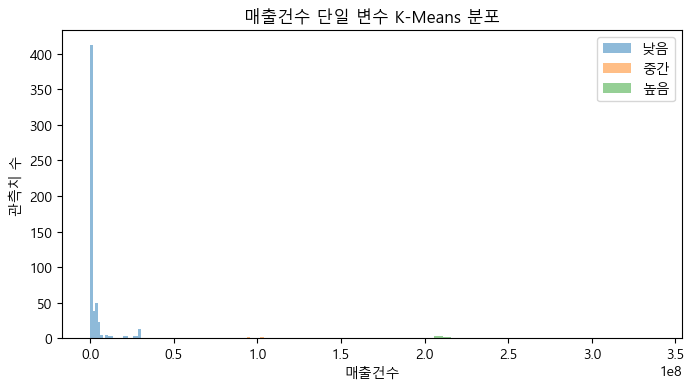

In [322]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_cnt_df[sales_cnt_df["sales_cnt_level"] == level]
    plt.hist(
        temp["sales_cnt"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("매출건수 단일 변수 K-Means 분포")
plt.xlabel("매출건수")
plt.ylabel("관측치 수")
plt.legend()
plt.show()


In [323]:
# 로그 변환
sales_cnt_df["sales_cnt_log"] = np.log1p(sales_cnt_df["sales_cnt"])

sales_cnt_df[["sales_cnt", "sales_cnt_log"]].head()


,sales_cnt,sales_cnt_log
0,999168.0,13.814679
1,1092318.0,13.903814
2,1113248.0,13.922793
3,1072653.0,13.885647
4,1043582.0,13.858171


In [324]:
X_sales_cnt_log = sales_cnt_df[["sales_cnt_log"]]

X_sales_cnt_log.head()


,sales_cnt_log
0,13.814679
1,13.903814
2,13.922793
3,13.885647
4,13.858171


In [325]:
scaler_sales_cnt_log = StandardScaler()
X_sales_cnt_log_scaled = scaler_sales_cnt_log.fit_transform(X_sales_cnt_log)

X_sales_cnt_log_scaled[:5]


array([[-0.39186412],
       [-0.33005302],
       [-0.31689128],
       [-0.34265112],
       [-0.36170461]])

In [326]:
kmeans_sales_cnt_log = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_cnt_df["sales_cnt_log_cluster_raw"] = kmeans_sales_cnt_log.fit_predict(
    X_sales_cnt_log_scaled
)

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw
0,2023Q1,41131510,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0


In [327]:
sales_cnt_log_order = (
    sales_cnt_df.groupby("sales_cnt_log_cluster_raw")["sales_cnt"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_cnt_log_order


[0, 2, 1]

In [328]:
sales_cnt_log_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_cnt_log_order)
}

sales_cnt_df["sales_cnt_log_cluster"] = sales_cnt_df["sales_cnt_log_cluster_raw"].map(
    sales_cnt_log_label_map
)

sales_cnt_df["sales_cnt_log_level"] = sales_cnt_df["sales_cnt_log_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw,sales_cnt_log_cluster,sales_cnt_log_level
0,2023Q1,41131510,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0,0,낮음
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0,0,낮음
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0,0,낮음
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0,0,낮음
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0,0,낮음


In [329]:
sales_cnt_df.groupby("sales_cnt_log_level")["sales_cnt"].mean().reindex(["낮음", "중간", "높음"])


sales_cnt_log_level
낮음    9.774944e+05
중간    5.157127e+06
높음    8.698984e+07
Name: sales_cnt, dtype: float64

In [330]:
sales_cnt_log_summary = (
    sales_cnt_df.groupby("sales_cnt_log_level")["sales_cnt"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_cnt_log_summary)


,count,mean,min,max
sales_cnt_log_level,,,,
낮음,432,9.774944e+05,130660.0,1934371.0
중간,109,5.157127e+06,2147996.0,12914486.0
높음,59,8.698984e+07,18623598.0,337137603.0


In [331]:
sales_cnt_log_silhouette = silhouette_score(
    X_sales_cnt_log_scaled,
    sales_cnt_df["sales_cnt_log_cluster"]
)

print("매출건수 로그변환 단일 변수 Silhouette Score:", sales_cnt_log_silhouette)


매출건수 로그변환 단일 변수 Silhouette Score: 0.6289449072466531


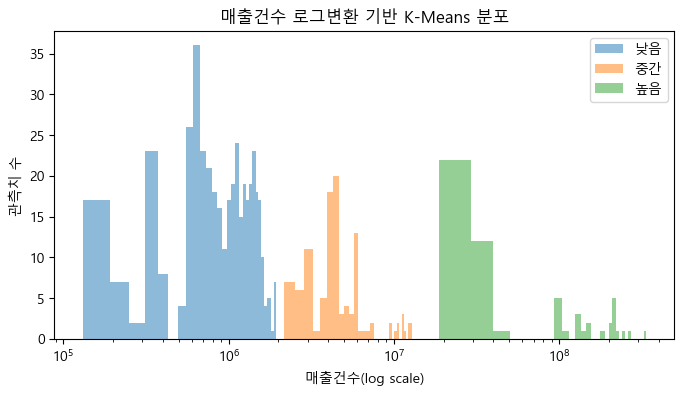

In [332]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_cnt_df[sales_cnt_df["sales_cnt_log_level"] == level]
    plt.hist(
        temp["sales_cnt"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.xscale("log")
plt.title("매출건수 로그변환 기반 K-Means 분포")
plt.xlabel("매출건수(log scale)")
plt.ylabel("관측치 수")
plt.legend()
plt.show()


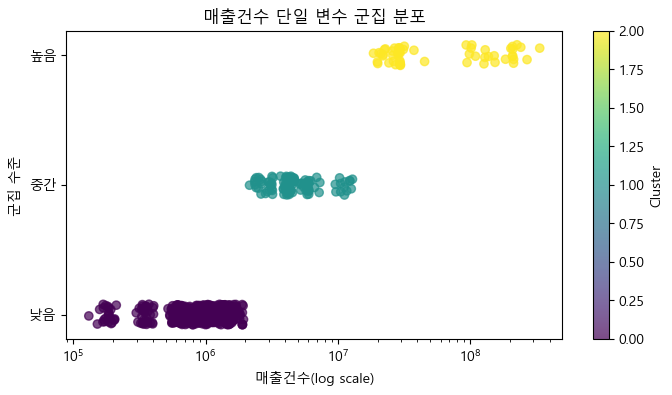

In [333]:
sales_cnt_df["sales_cnt_log_level_num"] = sales_cnt_df["sales_cnt_log_level"].map(LEVEL_TO_NUM)

rng = np.random.default_rng(RANDOM_STATE)

plt.figure(figsize=(8, 4))

y_jitter = sales_cnt_df["sales_cnt_log_level_num"] + rng.uniform(-0.08, 0.08, len(sales_cnt_df))

plt.scatter(
    sales_cnt_df["sales_cnt"],
    y_jitter,
    c=sales_cnt_df["sales_cnt_log_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.xscale("log")
plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("매출건수 단일 변수 군집 분포")
plt.xlabel("매출건수(log scale)")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()


매출건수는 실제 소비가 발생한 빈도를 나타내는 지표이다. 원본 매출건수 기준으로 K-Means를 수행했을 때는 일부 초대형 상권의 영향으로 대부분의 관측치가 낮음 그룹에 몰리고, 중간·높음 그룹은 각각 12개 관측치만 포함되는 극단적인 결과가 나타났다.

이에 따라 극단값의 영향을 완화하기 위해 매출건수에 log1p 변환을 적용한 후 StandardScaler로 표준화하여 K-Means를 다시 수행하였다.

로그변환 기반 K-Means 결과, 전체 600개 관측치는 낮음 432개, 중간 109개, 높음 59개로 구분되었다. 낮음 그룹의 평균 매출건수는 약 97.7만 건, 중간 그룹은 약 515.7만 건, 높음 그룹은 약 8,699만 건으로 나타났다.

Silhouette Score는 0.629로 나타났다. 이는 원본값 기준보다 낮아졌지만, 일부 극단값에 의해 군집이 과도하게 분리되는 문제를 완화하고 전체 분포를 더 균형 있게 구분한 결과로 해석할 수 있다.

따라서 매출건수 단일 변수 분석에서는 로그변환 기반 군집 결과를 중심으로 해석하는 것이 적절하다.

### 9.5 매출건수 비율


In [334]:
sales_cnt_df["sales_cnt_ratio"] = (
    sales_cnt_df["sales_cnt"] / 
    sales_cnt_df.groupby("base_quarter")["sales_cnt"].transform("sum")
)

sales_cnt_df["sales_cnt_ratio_pct"] = sales_cnt_df["sales_cnt_ratio"] * 100

sales_cnt_df[
    [
        "base_quarter",
        "adm_dong_cd",
        "adm_dong_nm",
        "gu",
        "sales_cnt",
        "sales_cnt_ratio",
        "sales_cnt_ratio_pct"
    ]
].head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_ratio,sales_cnt_ratio_pct
0,2023Q1,41131510,신흥1동,수정구,999168.0,0.002231,0.223103
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0.002306,0.230585
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0.002348,0.234826
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0.002280,0.227967
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0.002475,0.247516


In [335]:
sales_cnt_df.groupby("base_quarter")["sales_cnt"].transform("sum")


0      447851162.0
1      473716365.0
2      474073242.0
3      470530494.0
4      421621497.0
5      481716756.0
6      501954326.0
7      502917414.0
8      513472343.0
9      542830370.0
10     604616888.0
11     681504352.0
12     447851162.0
13     473716365.0
14     474073242.0
15     470530494.0
16     421621497.0
17     481716756.0
18     501954326.0
19     502917414.0
20     513472343.0
21     542830370.0
22     604616888.0
23     681504352.0
24     447851162.0
25     473716365.0
26     474073242.0
27     470530494.0
28     421621497.0
29     481716756.0
30     501954326.0
31     502917414.0
32     513472343.0
33     542830370.0
34     604616888.0
35     681504352.0
36     447851162.0
37     473716365.0
38     474073242.0
39     470530494.0
40     421621497.0
41     481716756.0
42     501954326.0
43     502917414.0
44     513472343.0
45     542830370.0
46     604616888.0
47     681504352.0
48     447851162.0
49     473716365.0
50     474073242.0
51     470530494.0
52     42162

In [336]:
sales_cnt_df["sales_cnt_ratio_pct"].describe()


count    600.000000
mean       2.000000
std        6.990740
min        0.023150
25%        0.146227
50%        0.245845
75%        0.617410
max       49.469619
Name: sales_cnt_ratio_pct, dtype: float64

In [337]:
X_sales_cnt_ratio = sales_cnt_df[["sales_cnt_ratio_pct"]]

X_sales_cnt_ratio.head()


,sales_cnt_ratio_pct
0,0.223103
1,0.230585
2,0.234826
3,0.227967
4,0.247516


In [338]:
scaler_sales_cnt_ratio = StandardScaler()
X_sales_cnt_ratio_scaled = scaler_sales_cnt_ratio.fit_transform(X_sales_cnt_ratio)

X_sales_cnt_ratio_scaled[:5]


array([[-0.25439079],
       [-0.25331961],
       [-0.25271239],
       [-0.25369443],
       [-0.2508956 ]])

In [339]:
kmeans_sales_cnt_ratio = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_cnt_df["sales_cnt_ratio_cluster_raw"] = kmeans_sales_cnt_ratio.fit_predict(
    X_sales_cnt_ratio_scaled
)

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw,sales_cnt_log_cluster,sales_cnt_log_level,sales_cnt_log_level_num,sales_cnt_ratio,sales_cnt_ratio_pct,sales_cnt_ratio_cluster_raw
0,2023Q1,41131510,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0,0,낮음,0,0.002231,0.223103,0
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0,0,낮음,0,0.002306,0.230585,0
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0,0,낮음,0,0.002348,0.234826,0
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0,0,낮음,0,0.002280,0.227967,0
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0,0,낮음,0,0.002475,0.247516,0


In [340]:
sales_cnt_ratio_order = (
    sales_cnt_df.groupby("sales_cnt_ratio_cluster_raw")["sales_cnt_ratio_pct"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_cnt_ratio_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_cnt_ratio_order)
}

sales_cnt_df["sales_cnt_ratio_cluster"] = sales_cnt_df[
    "sales_cnt_ratio_cluster_raw"
].map(sales_cnt_ratio_label_map)

sales_cnt_df["sales_cnt_ratio_level"] = sales_cnt_df[
    "sales_cnt_ratio_cluster"
].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw,sales_cnt_log_cluster,sales_cnt_log_level,sales_cnt_log_level_num,sales_cnt_ratio,sales_cnt_ratio_pct,sales_cnt_ratio_cluster_raw,sales_cnt_ratio_cluster,sales_cnt_ratio_level
0,2023Q1,41131510,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0,0,낮음,0,0.002231,0.223103,0,0,낮음
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0,0,낮음,0,0.002306,0.230585,0,0,낮음
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0,0,낮음,0,0.002348,0.234826,0,0,낮음
3,2023Q4,41131510,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0,0,낮음,0,0.002280,0.227967,0,0,낮음
4,2024Q1,41131510,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0,0,낮음,0,0.002475,0.247516,0,0,낮음


In [341]:
sales_cnt_df.groupby("sales_cnt_ratio_level")["sales_cnt_ratio_pct"].mean().reindex(
    ["낮음", "중간", "높음"]
)


sales_cnt_ratio_level
낮음     0.667803
중간    23.388284
높음    44.557164
Name: sales_cnt_ratio_pct, dtype: float64

In [342]:
sales_cnt_ratio_summary = (
    sales_cnt_df.groupby("sales_cnt_ratio_level")["sales_cnt_ratio_pct"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_cnt_ratio_summary)


,count,mean,min,max
sales_cnt_ratio_level,,,,
낮음,576,0.667803,0.023150,7.019039
중간,12,23.388284,20.893369,25.831531
높음,12,44.557164,41.921057,49.469619


In [343]:
sales_cnt_ratio_silhouette = silhouette_score(
    X_sales_cnt_ratio_scaled,
    sales_cnt_df["sales_cnt_ratio_cluster"]
)

print("매출건수 비율 단일 변수 Silhouette Score:", sales_cnt_ratio_silhouette)


매출건수 비율 단일 변수 Silhouette Score: 0.9551217410173998


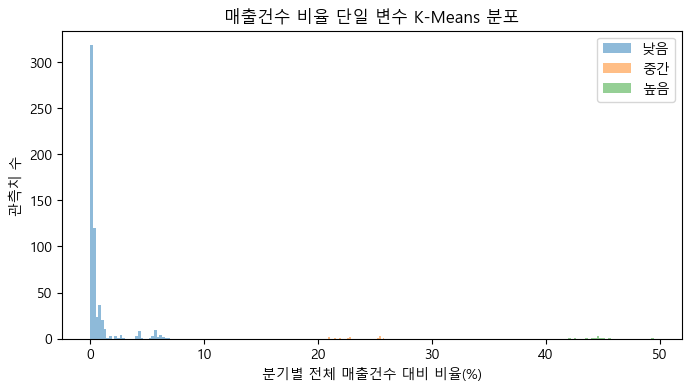

In [344]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_cnt_df[sales_cnt_df["sales_cnt_ratio_level"] == level]
    plt.hist(
        temp["sales_cnt_ratio_pct"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("매출건수 비율 단일 변수 K-Means 분포")
plt.xlabel("분기별 전체 매출건수 대비 비율(%)")
plt.ylabel("관측치 수")
plt.legend()
plt.show()


### 9.6 매출건수 QoQ 변화율


In [345]:
sales_cnt_df = ml_df[ID_COLUMNS + ["sales_cnt"]].copy()

sales_cnt_df["year"] = sales_cnt_df["base_quarter"].str[:4].astype(int)
sales_cnt_df["quarter"] = sales_cnt_df["base_quarter"].str[-1].astype(int)

sales_cnt_df = sales_cnt_df.sort_values(["adm_dong_cd", "year", "quarter"]).copy()

sales_cnt_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,year,quarter
0,2023Q1,41131510,신흥1동,수정구,999168.0,2023,1
1,2023Q2,41131510,신흥1동,수정구,1092318.0,2023,2
2,2023Q3,41131510,신흥1동,수정구,1113248.0,2023,3
3,2023Q4,41131510,신흥1동,수정구,1072653.0,2023,4
4,2024Q1,41131510,신흥1동,수정구,1043582.0,2024,1


In [346]:
sales_cnt_df["sales_cnt_qoq"] = (
    sales_cnt_df.groupby("adm_dong_cd")["sales_cnt"]
    .pct_change()
)

sales_cnt_df[[
    "base_quarter",
    "adm_dong_cd",
    "adm_dong_nm",
    "gu",
    "sales_cnt",
    "sales_cnt_qoq"
]].head(20)


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_qoq
0,2023Q1,41131510,신흥1동,수정구,999168.0,NaN
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0.093228
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0.019161
3,2023Q4,41131510,신흥1동,수정구,1072653.0,-0.036465
4,2024Q1,41131510,신흥1동,수정구,1043582.0,-0.027102
5,2024Q2,41131510,신흥1동,수정구,1031552.0,-0.011528
6,2024Q3,41131510,신흥1동,수정구,1045765.0,0.013778
7,2024Q4,41131510,신흥1동,수정구,985491.0,-0.057636
8,2025Q1,41131510,신흥1동,수정구,906277.0,-0.080380
9,2025Q2,41131510,신흥1동,수정구,937553.0,0.034510


In [347]:
sales_cnt_df["sales_cnt_qoq"].isna().sum()


np.int64(50)

In [348]:
sales_cnt_df["sales_cnt_qoq"].describe()


count    550.000000
mean       0.016136
std        0.108195
min       -0.472977
25%       -0.041478
50%        0.004206
75%        0.063339
max        1.020174
Name: sales_cnt_qoq, dtype: float64

In [349]:
lower = sales_cnt_df["sales_cnt_qoq"].quantile(0.01)
upper = sales_cnt_df["sales_cnt_qoq"].quantile(0.99)

sales_cnt_df["sales_cnt_qoq_clip"] = sales_cnt_df["sales_cnt_qoq"].clip(lower, upper)

print("하위 1%:", lower)
print("상위 1%:", upper)

sales_cnt_df[["sales_cnt_qoq", "sales_cnt_qoq_clip"]].describe()


하위 1%: -0.21473066118452575
상위 1%: 0.3130474966442577


,sales_cnt_qoq,sales_cnt_qoq_clip
count,550.000000,550.000000
mean,0.016136,0.014135
std,0.108195,0.085820
min,-0.472977,-0.214731
25%,-0.041478,-0.041478
50%,0.004206,0.004206
75%,0.063339,0.063339
max,1.020174,0.313047


In [350]:
# 분기별 중앙값 제거
sales_cnt_df["sales_cnt_qoq_adj"] = (
    sales_cnt_df["sales_cnt_qoq_clip"]
    - sales_cnt_df.groupby("base_quarter")["sales_cnt_qoq_clip"].transform("median")
)

sales_cnt_df[[
    "base_quarter",
    "adm_dong_cd",
    "adm_dong_nm",
    "gu",
    "sales_cnt",
    "sales_cnt_qoq",
    "sales_cnt_qoq_clip",
    "sales_cnt_qoq_adj"
]].head(20)


,base_quarter,adm_dong_cd,adm_dong_nm,gu,sales_cnt,sales_cnt_qoq,sales_cnt_qoq_clip,sales_cnt_qoq_adj
0,2023Q1,41131510,신흥1동,수정구,999168.0,NaN,NaN,NaN
1,2023Q2,41131510,신흥1동,수정구,1092318.0,0.093228,0.093228,-0.015663
2,2023Q3,41131510,신흥1동,수정구,1113248.0,0.019161,0.019161,0.013630
3,2023Q4,41131510,신흥1동,수정구,1072653.0,-0.036465,-0.036465,0.000534
4,2024Q1,41131510,신흥1동,수정구,1043582.0,-0.027102,-0.027102,0.005984
5,2024Q2,41131510,신흥1동,수정구,1031552.0,-0.011528,-0.011528,-0.063673
6,2024Q3,41131510,신흥1동,수정구,1045765.0,0.013778,0.013778,0.020882
7,2024Q4,41131510,신흥1동,수정구,985491.0,-0.057636,-0.057636,-0.030340
8,2025Q1,41131510,신흥1동,수정구,906277.0,-0.080380,-0.080380,0.000647
9,2025Q2,41131510,신흥1동,수정구,937553.0,0.034510,0.034510,-0.029382


| 변수                   | 의미                          |
| -------------------- | --------------------------- |
| `sales_cnt_qoq_clip` | 전분기 대비 매출건수 변화율             |
| `sales_cnt_qoq_adj`  | 같은 분기 전체 흐름 대비 상대적인 매출건수 변화 |


In [351]:
sales_cnt_qoq_col = "sales_cnt_qoq_adj"
sales_cnt_qoq_df = sales_cnt_df.dropna(subset=[sales_cnt_qoq_col]).copy()

X_sales_cnt_qoq_adj = sales_cnt_qoq_df[[sales_cnt_qoq_col]]
scaler_sales_cnt_qoq_adj = StandardScaler()
X_sales_cnt_qoq_adj_scaled = scaler_sales_cnt_qoq_adj.fit_transform(X_sales_cnt_qoq_adj)

kmeans_sales_cnt_qoq_adj = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
sales_cnt_qoq_df["sales_cnt_qoq_cluster_raw"] = kmeans_sales_cnt_qoq_adj.fit_predict(
    X_sales_cnt_qoq_adj_scaled
)

sales_cnt_qoq_silhouette = silhouette_score(
    X_sales_cnt_qoq_adj_scaled,
    sales_cnt_qoq_df["sales_cnt_qoq_cluster_raw"],
)
print("Silhouette Score:", round(sales_cnt_qoq_silhouette, 4))


Silhouette Score: 0.4919


In [352]:
sales_cnt_qoq_order = (
    sales_cnt_qoq_df.groupby("sales_cnt_qoq_cluster_raw")[sales_cnt_qoq_col]
    .mean()
    .sort_values()
    .index
)

sales_cnt_qoq_label_map = {
    old_label: LEVEL_ORDER[idx]
    for idx, old_label in enumerate(sales_cnt_qoq_order)
}

sales_cnt_qoq_df["sales_cnt_qoq_level"] = sales_cnt_qoq_df[
    "sales_cnt_qoq_cluster_raw"
].map(sales_cnt_qoq_label_map)

sales_cnt_qoq_df["sales_cnt_qoq_level"].value_counts()


sales_cnt_qoq_level
중간    316
낮음    207
높음     27
Name: count, dtype: int64

In [353]:
sales_cnt_qoq_summary = (
    sales_cnt_qoq_df.groupby("sales_cnt_qoq_level")[sales_cnt_qoq_col]
    .agg(["count", "mean", "min", "max"])
    .reindex(LEVEL_ORDER)
)

display(sales_cnt_qoq_summary)


,count,mean,min,max
sales_cnt_qoq_level,,,,
낮음,207,-0.044464,-0.212615,-0.012333
중간,316,0.021256,-0.011526,0.106049
높음,27,0.201775,0.120555,0.301826


In [354]:
sales_cnt_qoq_df[
    sales_cnt_qoq_df["sales_cnt_qoq_level"] == LEVEL_ORDER[2]
]["base_quarter"].value_counts().sort_index()


base_quarter
2023Q2    2
2023Q4    2
2024Q2    4
2024Q3    2
2024Q4    2
2025Q1    4
2025Q2    5
2025Q3    1
2025Q4    5
Name: count, dtype: int64

In [355]:
print("Silhouette Score:", round(sales_cnt_qoq_silhouette, 4))


Silhouette Score: 0.4919


| 수준 |  개수 |      평균 | 구간                |
| -- | --: | ------: | ----------------- |
| 낮음 | 207 |  -4.45% | -21.26% ~ -1.23%  |
| 중간 | 316 |  +2.13% | -1.15% ~ +10.60%  |
| 높음 |  27 | +20.18% | +12.06% ~ +30.18% |


매출건수 QoQ는 전분기 대비 소비활동 변화를 나타내는 지표로 생성하였다. 변화율 변수의 극단값 영향을 줄이기 위해 상·하위 1% clipping을 적용했으며, 특정 분기 전체의 증감 효과를 완화하기 위해 분기별 중앙값을 제거한 조정 QoQ 변수를 사용하였다. 단일변수 K-Means 결과 Silhouette Score는 0.4919로 나타났고, 낮음 207개, 중간 316개, 높음 27개로 구분되었다. 높음 그룹은 같은 분기 내에서 상대적으로 매출건수가 크게 증가한 행정동-분기로 해석하였다.

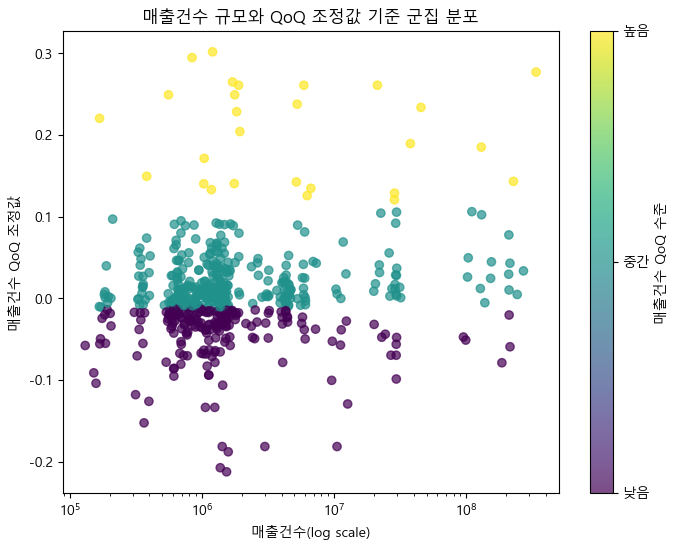

In [356]:
plot_df = sales_cnt_qoq_df.copy()

level_map = {
    "낮음": 0,
    "중간": 1,
    "높음": 2
}

plot_df["sales_cnt_qoq_level_num"] = plot_df["sales_cnt_qoq_level"].map(level_map)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    plot_df["sales_cnt"],
    plot_df["sales_cnt_qoq_adj"],
    c=plot_df["sales_cnt_qoq_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.xscale("log")
plt.xlabel("매출건수(log scale)")
plt.ylabel("매출건수 QoQ 조정값")
plt.title("매출건수 규모와 QoQ 조정값 기준 군집 분포")

cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["낮음", "중간", "높음"])
cbar.set_label("매출건수 QoQ 수준")

plt.show()


매출건수 규모는 100만 건 전후에 관측치가 집중되어 있으나, QoQ 조정값 기준으로는 소비활동 감소·보통·증가 그룹이 구분되어 단기 소비활동 변화 지표로 활용 가능하다고 판단하였다

유동인구 QoQ 조정값은 방문 수요 변화,
매출건수 QoQ 조정값은 소비활동 변화,
둘 다 젠트리피케이션의 상권 변화 압력 신호로 가져갈 수 있음.

### 9.7 프랜차이즈 침투율


In [357]:
franchise_df = ml_df[ID_COLUMNS + ["franchise_ratio"]].copy()

franchise_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,franchise_ratio
0,2023Q1,41131510,신흥1동,수정구,4.893482
1,2023Q2,41131510,신흥1동,수정구,4.843364
2,2023Q3,41131510,신흥1동,수정구,5.156809
3,2023Q4,41131510,신흥1동,수정구,5.164021
4,2024Q1,41131510,신흥1동,수정구,5.277544


In [358]:
X_franchise = franchise_df[["franchise_ratio"]]

X_franchise.head()


,franchise_ratio
0,4.893482
1,4.843364
2,5.156809
3,5.164021
4,5.277544


In [359]:
scaler_franchise = StandardScaler()
X_franchise_scaled = scaler_franchise.fit_transform(X_franchise)

X_franchise_scaled[:5]


array([[-0.5054022 ],
       [-0.52543237],
       [-0.40016277],
       [-0.39728044],
       [-0.35191059]])

In [360]:
kmeans_franchise = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

franchise_df["franchise_cluster_raw"] = kmeans_franchise.fit_predict(X_franchise_scaled)

franchise_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,franchise_ratio,franchise_cluster_raw
0,2023Q1,41131510,신흥1동,수정구,4.893482,1
1,2023Q2,41131510,신흥1동,수정구,4.843364,1
2,2023Q3,41131510,신흥1동,수정구,5.156809,1
3,2023Q4,41131510,신흥1동,수정구,5.164021,1
4,2024Q1,41131510,신흥1동,수정구,5.277544,1


In [361]:
franchise_order = (
    franchise_df.groupby("franchise_cluster_raw")["franchise_ratio"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

franchise_order


[1, 0, 2]

In [362]:
franchise_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(franchise_order)
}

franchise_df["franchise_cluster"] = franchise_df["franchise_cluster_raw"].map(franchise_label_map)

franchise_df["franchise_level"] = franchise_df["franchise_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

franchise_df.head()


,base_quarter,adm_dong_cd,adm_dong_nm,gu,franchise_ratio,franchise_cluster_raw,franchise_cluster,franchise_level
0,2023Q1,41131510,신흥1동,수정구,4.893482,1,0,낮음
1,2023Q2,41131510,신흥1동,수정구,4.843364,1,0,낮음
2,2023Q3,41131510,신흥1동,수정구,5.156809,1,0,낮음
3,2023Q4,41131510,신흥1동,수정구,5.164021,1,0,낮음
4,2024Q1,41131510,신흥1동,수정구,5.277544,1,0,낮음


In [363]:
franchise_df.groupby("franchise_level")["franchise_ratio"].mean().reindex(["낮음", "중간", "높음"])


franchise_level
낮음     4.521248
중간     7.141665
높음    13.308931
Name: franchise_ratio, dtype: float64

In [364]:
franchise_summary = (
    franchise_df.groupby("franchise_level")["franchise_ratio"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(franchise_summary)


,count,mean,min,max
franchise_level,,,,
낮음,317,4.521248,2.362056,5.825769
중간,244,7.141665,5.858271,9.957168
높음,39,13.308931,10.287420,18.465444


In [365]:
franchise_silhouette = silhouette_score(
    X_franchise_scaled,
    franchise_df["franchise_cluster"]
)

print("프랜차이즈 침투율 단일 변수 Silhouette Score:", franchise_silhouette)


프랜차이즈 침투율 단일 변수 Silhouette Score: 0.5882859530737554


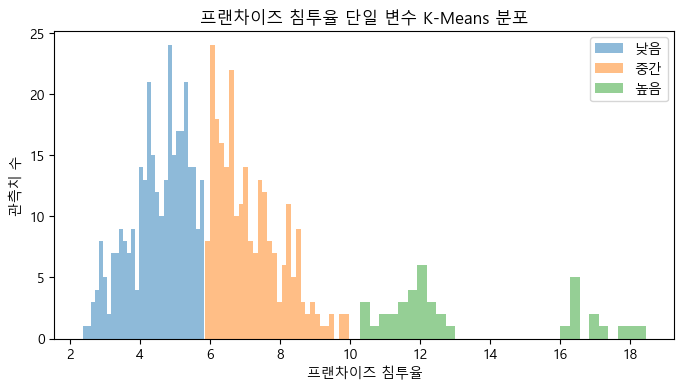

In [366]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = franchise_df[franchise_df["franchise_level"] == level]
    plt.hist(
        temp["franchise_ratio"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("프랜차이즈 침투율 단일 변수 K-Means 분포")
plt.xlabel("프랜차이즈 침투율")
plt.ylabel("관측치 수")
plt.legend()
plt.show()


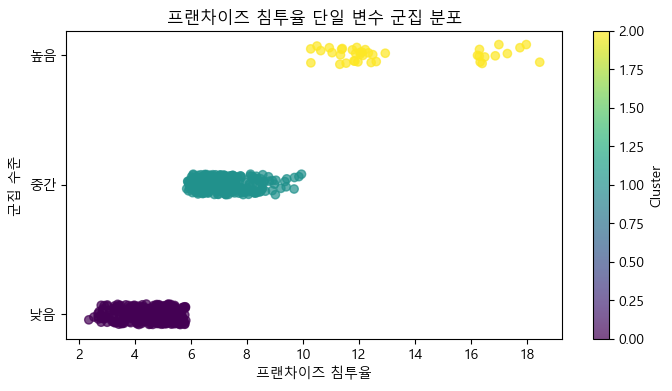

In [367]:
franchise_df["franchise_level_num"] = franchise_df["franchise_level"].map(LEVEL_TO_NUM)

rng = np.random.default_rng(RANDOM_STATE)

plt.figure(figsize=(8, 4))

y_jitter = franchise_df["franchise_level_num"] + rng.uniform(-0.08, 0.08, len(franchise_df))

plt.scatter(
    franchise_df["franchise_ratio"],
    y_jitter,
    c=franchise_df["franchise_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("프랜차이즈 침투율 단일 변수 군집 분포")
plt.xlabel("프랜차이즈 침투율")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()


프랜차이즈 침투율을 단일 변수로 K-Means 군집화한 결과, 전체 600개 행정동-분기 관측치는 낮음 317개, 중간 244개, 높음 39개로 구분되었다.

낮음 그룹의 평균 프랜차이즈 침투율은 약 4.52, 중간 그룹은 약 7.14, 높음 그룹은 약 13.31로 나타났다. 이는 프랜차이즈 침투율이 낮은 일반 상권, 중간 수준의 프랜차이즈화 상권, 프랜차이즈 침투율이 높은 상권으로 구분됨을 의미한다.

Silhouette Score는 0.588로 나타나 군집 분리가 매우 강하다고 보기는 어렵지만, 낮음·중간·높음 수준으로 해석 가능한 정도의 구분은 확인되었다.

프랜차이즈 침투율이 높은 그룹은 로컬 상권보다 프랜차이즈 중심 상권으로 변화했을 가능성이 있는 지역으로 볼 수 있으며, 젠트리피케이션 위험 후보를 판단할 때 중요한 보조 지표로 활용할 수 있다.

In [368]:
franchise_df[franchise_df["franchise_level"] == "높음"][
    ["base_quarter", "adm_dong_cd", "adm_dong_nm", "gu", "franchise_ratio", "franchise_level"]
].sort_values(["adm_dong_nm", "base_quarter"])


,base_quarter,adm_dong_cd,adm_dong_nm,gu,franchise_ratio,franchise_level
540,2023Q1,41135657,백현동,분당구,17.006677,높음
541,2023Q2,41135657,백현동,분당구,17.310596,높음
542,2023Q3,41135657,백현동,분당구,17.759444,높음
543,2023Q4,41135657,백현동,분당구,17.986600,높음
544,2024Q1,41135657,백현동,분당구,18.465444,높음
545,2024Q2,41135657,백현동,분당구,16.879401,높음
546,2024Q3,41135657,백현동,분당구,16.501742,높음
547,2024Q4,41135657,백현동,분당구,16.409594,높음
548,2025Q1,41135657,백현동,분당구,16.313616,높음
549,2025Q2,41135657,백현동,분당구,16.305572,높음


In [369]:
franchise_df[franchise_df["franchise_level"] == "높음"] \
    .groupby(["adm_dong_cd", "adm_dong_nm", "gu"]) \
    .size() \
    .reset_index(name="count") \
    .sort_values("count", ascending=False)


,adm_dong_cd,adm_dong_nm,gu,count
0,41135520,수내1동,분당구,12
2,41135580,서현1동,분당구,12
3,41135657,백현동,분당구,12
1,41135550,정자1동,분당구,3


| 행정동  | 높음 그룹 포함 횟수 |
| ---- | ----------: |
| 백현동  |          12 |
| 서현1동 |          12 |
| 수내1동 |          12 |
| 정자1동 |           3 |


프랜차이즈 침투율 단일 변수 K-Means 결과, 높음 그룹에는 백현동, 서현1동, 수내1동이 각각 12개 분기 모두 포함되었고, 정자1동은 3개 분기만 포함되었다.

이는 백현동, 서현1동, 수내1동이 분석 기간 동안 지속적으로 프랜차이즈 침투율이 높은 상권임을 의미한다. 따라서 해당 지역들은 로컬 상권 대비 프랜차이즈화 정도가 높은 지역으로 해석할 수 있다.

반면 정자1동은 매출액과 매출건수 측면에서는 초고활성 대형 상권으로 나타났지만, 프랜차이즈 침투율 기준으로는 일부 분기만 높은 그룹에 포함되었다. 따라서 정자1동은 프랜차이즈 침투형보다는 매출 규모가 압도적으로 큰 대형 상권으로 구분하는 것이 적절하다.

In [370]:
franchise_df[
    (franchise_df["adm_dong_nm"] == "정자1동") &
    (franchise_df["franchise_level"] == "높음")
][
    ["base_quarter", "adm_dong_cd", "adm_dong_nm", "gu", "franchise_ratio", "franchise_level"]
].sort_values("base_quarter")


,base_quarter,adm_dong_cd,adm_dong_nm,gu,franchise_ratio,franchise_level
401,2024Q2,41135550,정자1동,분당구,10.510315,높음
402,2024Q3,41135550,정자1동,분당구,10.287420,높음
403,2024Q4,41135550,정자1동,분당구,10.292675,높음


정자1동은 프랜차이즈 침투율 기준으로 2024Q2, 2024Q3, 2024Q4 총 3개 분기에서만 높음 그룹에 포함되었다. 따라서 정자1동은 전 기간에 걸친 프랜차이즈 침투형보다는, 매출 규모가 매우 큰 초고활성 대형 상권으로 해석하는 것이 적절하다.


In [371]:
franchise_df[
    franchise_df["adm_dong_nm"].isin(["백현동", "서현1동", "수내1동", "정자1동"])
][
    ["base_quarter", "adm_dong_cd", "adm_dong_nm", "gu", "franchise_ratio", "franchise_level"]
].sort_values(["adm_dong_nm", "base_quarter"])


,base_quarter,adm_dong_cd,adm_dong_nm,gu,franchise_ratio,franchise_level
540,2023Q1,41135657,백현동,분당구,17.006677,높음
541,2023Q2,41135657,백현동,분당구,17.310596,높음
542,2023Q3,41135657,백현동,분당구,17.759444,높음
543,2023Q4,41135657,백현동,분당구,17.986600,높음
544,2024Q1,41135657,백현동,분당구,18.465444,높음
545,2024Q2,41135657,백현동,분당구,16.879401,높음
546,2024Q3,41135657,백현동,분당구,16.501742,높음
547,2024Q4,41135657,백현동,분당구,16.409594,높음
548,2025Q1,41135657,백현동,분당구,16.313616,높음
549,2025Q2,41135657,백현동,분당구,16.305572,높음


### 9.8 유동인구와 외부유입인구 4분기-QoQ 파생변수 테이블

`floating_pop`과 `external_inflow`만 따로 뽑아 최근 4분기 이동평균, 변화량, 추세, QoQ를 한 테이블로 정리한다.


In [ ]:
external_inflow_col = detect_column(
    df,
    ["external_inflow", "external_inflow_pop", "outside_inflow"],
)
floating_pop_col = detect_column(df, ["floating_pop"])

population_base_cols = [
    quarter_col,
    adm_cd_col,
    adm_nm_col,
    gu_col,
    floating_pop_col,
    external_inflow_col,
]
if year_col is not None:
    population_base_cols.append(year_col)
if q_col is not None:
    population_base_cols.append(q_col)

population_base_cols = list(dict.fromkeys(population_base_cols))
population_rename_cols = {
    quarter_col: "base_quarter",
    adm_cd_col: "adm_dong_cd",
    adm_nm_col: "adm_dong_nm",
    gu_col: "gu",
    floating_pop_col: "floating_pop",
    external_inflow_col: "external_inflow",
}
if year_col is not None:
    population_rename_cols[year_col] = "year"
if q_col is not None:
    population_rename_cols[q_col] = "quarter"

population_feature_df = df[population_base_cols].rename(columns=population_rename_cols).copy()

if "year" not in population_feature_df.columns:
    population_feature_df["year"] = (
        population_feature_df["base_quarter"].astype(str).str.extract(r"(\d{4})")[0]
    )
if "quarter" not in population_feature_df.columns:
    population_feature_df["quarter"] = (
        population_feature_df["base_quarter"].astype(str).str.extract(r"([1-4])")[0]
    )

population_feature_df["year"] = pd.to_numeric(population_feature_df["year"], errors="coerce")
population_feature_df["quarter"] = pd.to_numeric(population_feature_df["quarter"], errors="coerce")

population_feature_df = population_feature_df.sort_values(
    ["adm_dong_cd", "year", "quarter", "base_quarter"]
).reset_index(drop=True)


def rolling_slope_4q(values):
    values = pd.Series(values).dropna().astype(float)
    if len(values) < 2:
        return np.nan
    x = np.arange(len(values), dtype=float)
    return np.polyfit(x, values, 1)[0]


def add_population_features(frame, source_col, prefix):
    group = frame.groupby("adm_dong_cd")[source_col]
    prev_qoq = group.shift(1)
    prev_yoy = frame.groupby(["adm_dong_cd", "quarter"])[source_col].shift(1)

    frame[f"{prefix}_log"] = np.log1p(frame[source_col].clip(lower=0))
    frame[f"{prefix}_prev_qoq"] = prev_qoq
    frame[f"{prefix}_prev_yoy"] = prev_yoy

    frame[f"{prefix}_qoq"] = np.where(
        prev_qoq.notna() & (prev_qoq != 0),
        ((frame[source_col] - prev_qoq) / prev_qoq) * 100,
        np.nan,
    )
    frame[f"{prefix}_yoy"] = np.where(
        prev_yoy.notna() & (prev_yoy != 0),
        ((frame[source_col] - prev_yoy) / prev_yoy) * 100,
        np.nan,
    )

    qoq_clean = frame[f"{prefix}_qoq"].replace([np.inf, -np.inf], np.nan)
    lower = qoq_clean.quantile(0.01)
    upper = qoq_clean.quantile(0.99)
    frame[f"{prefix}_qoq_clip"] = qoq_clean.clip(lower=lower, upper=upper)
    frame[f"{prefix}_qoq_adj"] = (
        frame[f"{prefix}_qoq_clip"]
        - frame.groupby("base_quarter")[f"{prefix}_qoq_clip"].transform("median")
    )

    frame[f"{prefix}_recent4_mean"] = group.transform(
        lambda s: s.rolling(4, min_periods=1).mean()
    )
    frame[f"{prefix}_recent4_mean_log"] = np.log1p(
        frame[f"{prefix}_recent4_mean"].clip(lower=0)
    )
    frame[f"{prefix}_recent4_change"] = group.diff(3)
    frame[f"{prefix}_slope_4q"] = group.transform(
        lambda s: s.rolling(4, min_periods=2).apply(rolling_slope_4q, raw=False)
    )

    frame[f"{prefix}_qoq_missing"] = frame[f"{prefix}_qoq"].isna().astype(int)
    frame[f"{prefix}_yoy_missing"] = frame[f"{prefix}_yoy"].isna().astype(int)
    frame[f"{prefix}_slope_4q_missing"] = frame[f"{prefix}_slope_4q"].isna().astype(int)

    return frame


for source_col, prefix in [
    ("floating_pop", "floating_pop"),
    ("external_inflow", "external_inflow"),
]:
    population_feature_df = add_population_features(population_feature_df, source_col, prefix)

population_feature_df["external_inflow_ratio"] = np.where(
    population_feature_df["floating_pop"] > 0,
    (population_feature_df["external_inflow"] / population_feature_df["floating_pop"]) * 100,
    np.nan,
)

population_feature_meta = pd.DataFrame([
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop", "feature_type": "raw", "calculation": "original value", "model_use_note": "current scale"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_log", "feature_type": "log", "calculation": "log1p(floating_pop)", "model_use_note": "scale with outlier compression"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_recent4_mean", "feature_type": "recent 4Q", "calculation": "rolling mean over last 4 quarters", "model_use_note": "stable recent scale"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_recent4_mean_log", "feature_type": "recent 4Q log", "calculation": "log1p(recent4_mean)", "model_use_note": "stable recent scale with outlier compression"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_recent4_change", "feature_type": "recent 4Q change", "calculation": "current quarter - value 3 quarters ago", "model_use_note": "recent 4-quarter amount change"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_slope_4q", "feature_type": "recent 4Q slope", "calculation": "linear slope over last 4 quarters", "model_use_note": "recent trend"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_qoq", "feature_type": "QoQ", "calculation": "quarter-over-quarter change rate (%)", "model_use_note": "short-term change"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_qoq_adj", "feature_type": "QoQ adjusted", "calculation": "1%-99% clipped QoQ - quarter median", "model_use_note": "relative change within same quarter"},
    {"variable_label": "\uc720\ub3d9\uc778\uad6c", "source_variable": "floating_pop", "feature_name": "floating_pop_yoy", "feature_type": "YoY", "calculation": "same-quarter year-over-year change rate (%)", "model_use_note": "seasonality-adjusted annual change"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow", "feature_type": "raw", "calculation": "original value", "model_use_note": "current scale"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_log", "feature_type": "log", "calculation": "log1p(external_inflow)", "model_use_note": "scale with outlier compression"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_recent4_mean", "feature_type": "recent 4Q", "calculation": "rolling mean over last 4 quarters", "model_use_note": "stable recent scale"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_recent4_mean_log", "feature_type": "recent 4Q log", "calculation": "log1p(recent4_mean)", "model_use_note": "stable recent scale with outlier compression"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_recent4_change", "feature_type": "recent 4Q change", "calculation": "current quarter - value 3 quarters ago", "model_use_note": "recent 4-quarter amount change"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_slope_4q", "feature_type": "recent 4Q slope", "calculation": "linear slope over last 4 quarters", "model_use_note": "recent trend"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_qoq", "feature_type": "QoQ", "calculation": "quarter-over-quarter change rate (%)", "model_use_note": "short-term change"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_qoq_adj", "feature_type": "QoQ adjusted", "calculation": "1%-99% clipped QoQ - quarter median", "model_use_note": "relative change within same quarter"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_yoy", "feature_type": "YoY", "calculation": "same-quarter year-over-year change rate (%)", "model_use_note": "seasonality-adjusted annual change"},
    {"variable_label": "\uc678\ubd80\uc720\uc785\uc778\uad6c", "source_variable": "external_inflow", "feature_name": "external_inflow_ratio", "feature_type": "ratio", "calculation": "external_inflow / floating_pop * 100", "model_use_note": "external inflow share among floating population"},
])

population_feature_columns = [
    "base_quarter",
    "adm_dong_cd",
    "adm_dong_nm",
    "gu",
    "year",
    "quarter",
    "floating_pop",
    "floating_pop_log",
    "floating_pop_recent4_mean",
    "floating_pop_recent4_mean_log",
    "floating_pop_recent4_change",
    "floating_pop_slope_4q",
    "floating_pop_qoq",
    "floating_pop_qoq_adj",
    "floating_pop_yoy",
    "external_inflow",
    "external_inflow_log",
    "external_inflow_ratio",
    "external_inflow_recent4_mean",
    "external_inflow_recent4_mean_log",
    "external_inflow_recent4_change",
    "external_inflow_slope_4q",
    "external_inflow_qoq",
    "external_inflow_qoq_adj",
    "external_inflow_yoy",
]

population_feature_table = population_feature_df[population_feature_columns].copy()

population_feature_meta_display = population_feature_meta.drop(columns=["owner"], errors="ignore").rename(columns={
    "variable_label": "\uad6c\ubd84",
    "source_variable": "\uc6d0\ubcf8\ubcc0\uc218",
    "feature_name": "\ud30c\uc0dd\ubcc0\uc218",
    "feature_type": "\uc720\ud615",
    "calculation": "\uacc4\uc0b0\ubc29\uc2dd",
    "model_use_note": "\uc0ac\uc6a9\uba54\ubaa8",
})

POPULATION_FEATURE_TABLE_PATH = OUTPUT_DIR / "population_floating_external_inflow_features.csv"
POPULATION_FEATURE_META_PATH = OUTPUT_DIR / "population_floating_external_inflow_feature_meta.csv"

population_feature_table.to_csv(POPULATION_FEATURE_TABLE_PATH, index=False, encoding="utf-8-sig")
population_feature_meta_display.to_csv(POPULATION_FEATURE_META_PATH, index=False, encoding="utf-8-sig")

print("population feature table:", POPULATION_FEATURE_TABLE_PATH)
print("population feature meta:", POPULATION_FEATURE_META_PATH)
display(population_feature_meta_display)
display(population_feature_table.head(20))


## 10. 최종 변수 후보 및 종합 해석


| 변수                     | 역할                  |
| ---------------------- | ------------------- |
| `sales_amt_log`        | 현재 상권 경제 규모         |
| `floating_pop_qoq_adj` | 상대적 방문 수요 변화        |
| `sales_cnt_qoq_adj`    | 상대적 소비 활동 변화        |
| `franchise_ratio`      | 프랜차이즈 침투율 / 브랜드화 정도 |


1. 각 변수의 역할이 겹치지 않음
2. 단일변수 분포/군집 상태가 괜찮음
3. 결측치가 많지 않음
4. 극단값 처리가 되어 있음
5. 다변수 K-Means 결과 군집 개수가 너무 쏠리지 않음
6. 군집별 평균 특성이 해석 가능함
7. Silhouette Score가 너무 낮지 않음

| 변수                  | 문제                    |
| ------------------- | --------------------- |
| 유동인구 + 외부유입 인구      | 둘 다 유입/방문 수요라 겹칠 수 있음 |
| 매출액 + 매출건수          | 둘 다 상권 소비 규모라 겹칠 수 있음 |
| 프랜차이즈 침투율 + 프랜차이즈 수 | 프랜차이즈 관련 중복 가능성 큼     |
| 신규기업 수              | 원본 수로 넣으면 행정동 규모 영향 큼 |
| 상권활력도               | 좋음, 다만 계산식 명확해야 함     |


| 원래 변수     | ML에 넣을 추천 형태                                         | 역할       |
| --------- | ---------------------------------------------------- | -------- |
| 신규기업 증가율    | `new_corp_cnt_log` 또는 `new_corp_qoq_adj`             | 신규 진입    |
| 유동인구 변화율     | `floating_pop_qoq_adj`                               | 방문 수요 변화 |
| 외부유입 인구 증가율   | `external_inflow_ratio` 또는 `external_inflow_qoq_adj` | 외부 방문 수요 |
| 매출액  log     | `sales_amt_log`                                      | 상권 경제 규모 |
| 매출건수 변화율     | `sales_cnt_qoq_adj`                                  | 소비 활동 변화 |
| 프랜차이즈 침투율 | `franchise_ratio`                                    | 브랜드화 정도  |
| 상권활력도     | `open_rate - close_rate` 또는 `net_open_rate`          | 상권 진입/이탈 |
| 프랜차이즈 증가율   | 가능하면 제외, 또는 `franchise_cnt_log` 보조                   | 프랜차이즈 증가율 |

### 지역별 해석 요약

- 정자1동: 초고활성 대형 상권
- 백현동: 프랜차이즈 침투 위험 후보
- 서현1동·수내1동: 프랜차이즈화 관찰 지역
- 운중동: 중상위 활성 상권으로 전환
- 금곡동·시흥동: 일시적 활성화


초기 분석에서는 분기별 데이터를 기준으로 유동인구, 매출액, 매출건수, 프랜차이즈 비율의 분포와 군집 가능성을 확인하였다.
이를 통해 변수별 스케일 차이, 이상치, 프랜차이즈 비율의 영향 등을 파악했고,
최종 모델에서는 이를 바탕으로 행정동 단위 변화율 feature를 생성하였다.

## 최종 해석

K-Means 군집분석 결과, 성남시 행정동-분기 단위 상권은 4개 유형으로 분류되었다. cluster 0은 일반/저활력 상권형, cluster 1은 프랜차이즈 침투 고위험형, cluster 2는 중상위 활성 상권형, cluster 3은 초고활성 대형 상권형으로 해석할 수 있다. 특히 백현동은 프랜차이즈 침투율이 높은 고위험 후보로, 정자1동은 매출 규모가 큰 초고활성 대형 상권으로 구분된다.

## 11. 행정동별 최종 결과 확인

최종 K-Means 결과를 행정동 단위로 요약하고, 분기별 군집 변화를 행정동별로 확인한다.


In [372]:
latest_quarter = ml_df["base_quarter"].max()

latest_admin_dong_cluster = (
    ml_df[ml_df["base_quarter"] == latest_quarter]
    [ID_COLUMNS + ["cluster", "cluster_label"] + FEATURES]
    .sort_values(["cluster", "gu", "adm_dong_nm"])
)

def most_common_cluster(series):
    return series.mode().iat[0]

admin_dong_summary = (
    ml_df.sort_values(["adm_dong_cd", "base_quarter"])
    .groupby(["adm_dong_cd", "adm_dong_nm", "gu"], as_index=False)
    .agg(
        quarter_count=("base_quarter", "nunique"),
        main_cluster=("cluster", most_common_cluster),
        cluster_nunique=("cluster", "nunique"),
        latest_quarter=("base_quarter", "last"),
        latest_cluster=("cluster", "last"),
        latest_cluster_label=("cluster_label", "last"),
        avg_floating_pop=("floating_pop", "mean"),
        avg_sales_amt=("sales_amt", "mean"),
        avg_sales_cnt=("sales_cnt", "mean"),
        avg_franchise_ratio=("franchise_ratio", "mean"),
    )
)

admin_dong_summary["main_cluster_label"] = admin_dong_summary["main_cluster"].map(CLUSTER_LABELS)
admin_dong_summary = admin_dong_summary[
    [
        "adm_dong_cd",
        "adm_dong_nm",
        "gu",
        "quarter_count",
        "main_cluster",
        "main_cluster_label",
        "cluster_nunique",
        "latest_quarter",
        "latest_cluster",
        "latest_cluster_label",
        "avg_floating_pop",
        "avg_sales_amt",
        "avg_sales_cnt",
        "avg_franchise_ratio",
    ]
].sort_values(["latest_cluster", "gu", "adm_dong_nm"])

ADMIN_DONG_SUMMARY_PATH = OUTPUT_DIR / "ML용_kmeans_행정동별_요약.csv"
admin_dong_summary.to_csv(ADMIN_DONG_SUMMARY_PATH, index=False, encoding="utf-8-sig")

print(f"최근 분기: {latest_quarter}")
print(f"행정동별 요약 저장: {ADMIN_DONG_SUMMARY_PATH}")
display(latest_admin_dong_cluster)
display(admin_dong_summary)


최근 분기: 2025Q4
행정동별 요약 저장: ..\data\ML용_kmeans_행정동별_요약.csv


,base_quarter,adm_dong_cd,adm_dong_nm,gu,cluster,cluster_label,floating_pop,sales_amt,sales_cnt,franchise_ratio
575,2025Q4,41135665,구미1동,분당구,0,일반/기준 상권형,3094782.52,8.715235e+10,2364288.0,4.507711
563,2025Q4,41135662,금곡동,분당구,0,일반/기준 상권형,4274078.89,1.157537e+11,3033591.0,5.221732
347,2025Q4,41135510,분당동,분당구,0,일반/기준 상권형,2344109.54,1.398363e+10,569494.0,6.839378
455,2025Q4,41135590,서현2동,분당구,0,일반/기준 상권형,2143217.75,3.235886e+10,1472598.0,4.364592
371,2025Q4,41135530,수내2동,분당구,0,일반/기준 상권형,527560.41,2.021799e+10,712543.0,2.702703
383,2025Q4,41135540,수내3동,분당구,0,일반/기준 상권형,1281960.46,2.098975e+10,912178.0,6.949916
503,2025Q4,41135630,야탑2동,분당구,0,일반/기준 상권형,1131859.42,3.165680e+10,1058571.0,3.593846
515,2025Q4,41135640,야탑3동,분당구,0,일반/기준 상권형,3604333.85,2.797842e+10,1084082.0,4.317032
467,2025Q4,41135600,이매1동,분당구,0,일반/기준 상권형,2864685.67,2.641161e+10,1093901.0,6.701521
479,2025Q4,41135610,이매2동,분당구,0,일반/기준 상권형,794085.81,1.334944e+10,592944.0,5.035686


,adm_dong_cd,adm_dong_nm,gu,quarter_count,main_cluster,main_cluster_label,cluster_nunique,latest_quarter,latest_cluster,latest_cluster_label,avg_floating_pop,avg_sales_amt,avg_sales_cnt,avg_franchise_ratio
47,41135665,구미1동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,2.963525e+06,8.423567e+10,2.470700e+06,4.978768
46,41135662,금곡동,분당구,12,0,일반/기준 상권형,2,2025Q4,0,일반/기준 상권형,4.134888e+06,1.119265e+11,3.100550e+06,5.426654
28,41135510,분당동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,2.365421e+06,1.351593e+10,5.896972e+05,7.320291
37,41135590,서현2동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,2.054209e+06,3.165216e+10,1.524326e+06,5.010176
30,41135530,수내2동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,3.525969e+05,1.961419e+10,6.920214e+05,3.100418
31,41135540,수내3동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,1.347623e+06,1.971457e+10,9.168098e+05,7.214323
41,41135630,야탑2동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,1.022685e+06,3.686644e+10,1.327919e+06,4.214892
42,41135640,야탑3동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,3.428562e+06,2.059677e+10,8.321829e+05,4.961126
38,41135600,이매1동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,2.841799e+06,2.713280e+10,1.131018e+06,6.704236
39,41135610,이매2동,분당구,12,0,일반/기준 상권형,1,2025Q4,0,일반/기준 상권형,7.295388e+05,1.292043e+10,5.909518e+05,5.931603


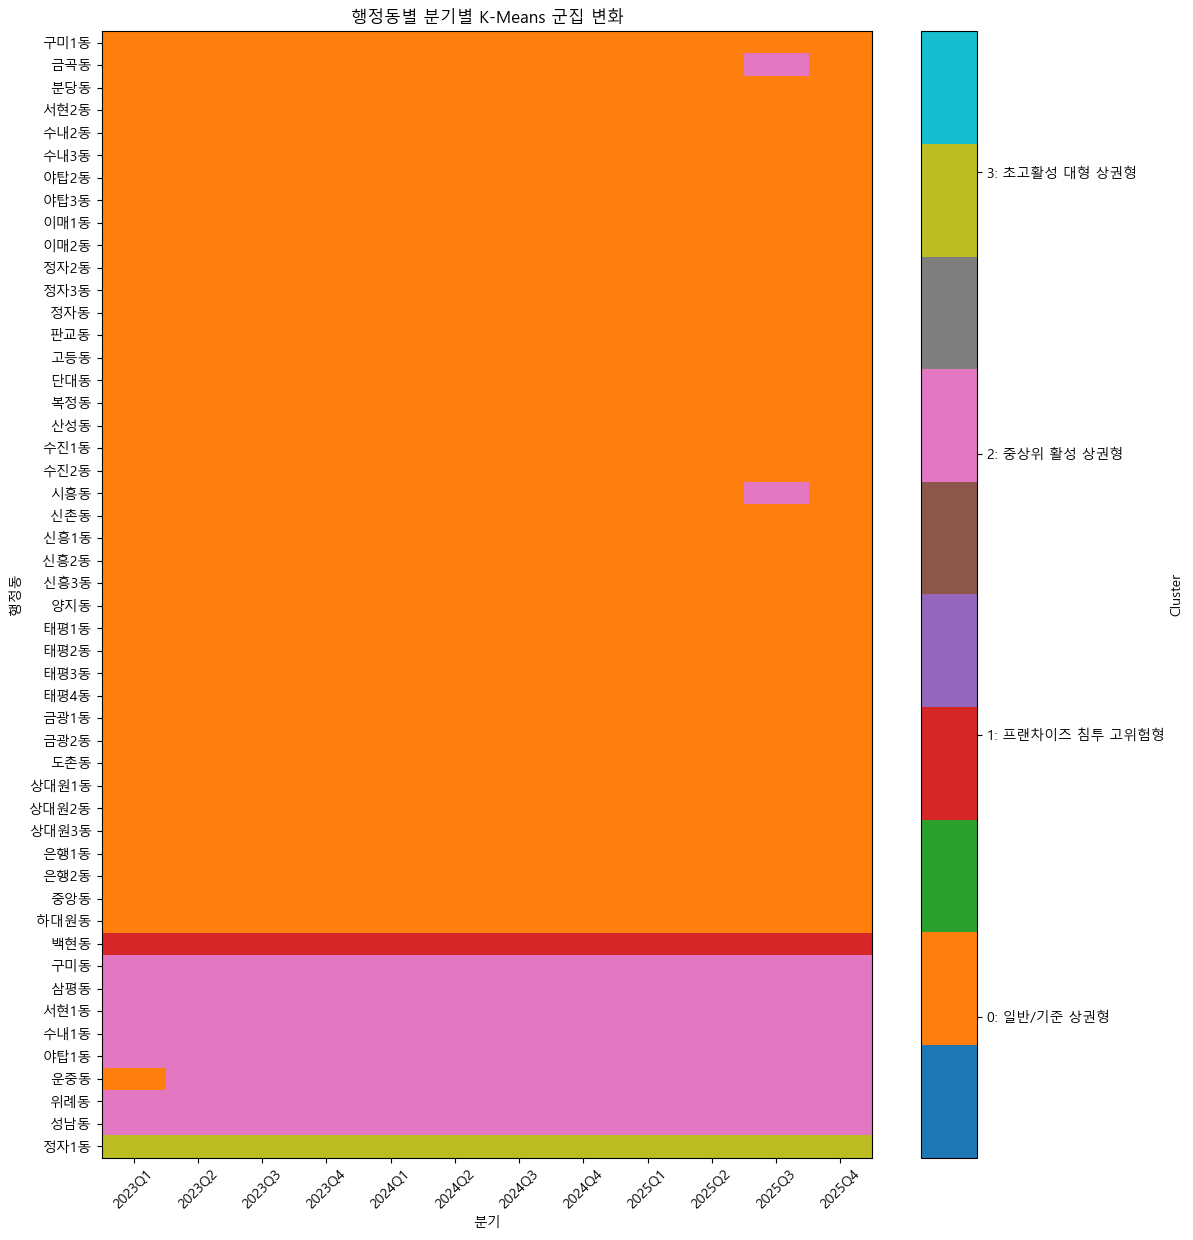

In [373]:
admin_dong_cluster_pivot = (
    ml_df.pivot_table(
        index="adm_dong_nm",
        columns="base_quarter",
        values="cluster",
        aggfunc="first",
    )
)

plot_order = admin_dong_summary.sort_values(
    ["latest_cluster", "gu", "adm_dong_nm"]
)["adm_dong_nm"]
plot_pivot = admin_dong_cluster_pivot.loc[plot_order]

plt.figure(figsize=(12, max(8, len(plot_pivot) * 0.25)))
plt.imshow(plot_pivot, aspect="auto", cmap="tab10", vmin=-0.5, vmax=N_CLUSTERS - 0.5)
plt.xticks(range(len(plot_pivot.columns)), plot_pivot.columns, rotation=45)
plt.yticks(range(len(plot_pivot.index)), plot_pivot.index)
plt.xlabel("분기")
plt.ylabel("행정동")
plt.title("행정동별 분기별 K-Means 군집 변화")

cbar = plt.colorbar(ticks=range(N_CLUSTERS))
cbar.ax.set_yticklabels([f"{cluster}: {CLUSTER_LABELS[cluster]}" for cluster in range(N_CLUSTERS)])
cbar.set_label("Cluster")

plt.tight_layout()
plt.show()
